In [1]:
import pandas as pd
import obspy
import numpy as np
from seismicif.datamod.loading_utils import (
    preproc_flow_annotations,
    extract_split_flows,
    find_date_in_strings,
    sliding_windows_from_stream,
)
from seismicif.datamod.preproc_utils import preproc_stream
from matplotlib import pyplot as plt
import pickle
from scipy.cluster.hierarchy import linkage, dendrogram
from scipy.spatial.distance import squareform
import scipy.cluster.hierarchy as sch
from seismicif.datamod.trigger_utils import stream_trigger_detections
from seismicif.isolation_forest import train_if, compute_scores, create_if_stream
from seismicif.metrics import (
    iou,
    est_thresholds,
    extract_valid_segments,
    compute_statistics,
    find_fp_fn,
)
from scipy.cluster.hierarchy import fcluster, cophenet

from joblib import load
from seismicif.dtw import template_dtw, get_merge_height, remove_singleton_merges
from seismicif.datamod.loading_utils import find_paths
import os

from dynamicTreeCut import cutreeHybrid
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
import matplotlib.pyplot as plt


def min_height_for_group(linkage_matrix, observations):
    # Track clusters formed when merging
    n = len(linkage_matrix) + 1  # Number of original observations
    clusters = {i: {i} for i in range(n)}

    for i, (c1, c2, height, _) in enumerate(linkage_matrix):
        new_cluster = clusters[int(c1)] | clusters[int(c2)]
        new_id = n + i  # new cluster index in hierarchy
        clusters[new_id] = new_cluster

        if set(observations).issubset(new_cluster):
            return height

    return None


import numpy as np
from scipy.stats import norm
from scipy.optimize import minimize


# --- Tukey g-and-h transformation ---
def g_and_h(z, g, h):
    if np.isclose(g, 0):
        return z * np.exp(h * z**2 / 2)
    return (np.exp(g * z) - 1) / g * np.exp(h * z**2 / 2)


# --- Quantile function for g-and-h (for computing quartiles) ---
def g_and_h_ppf(p, g, h):
    z = norm.ppf(p)
    return g_and_h(z, g, h)


# --- Step 1: Fit g,h,a,b by quantile matching ---
def fit_gandh(x):
    x = np.sort(x)
    q_data = np.percentile(x, [25, 50, 75])

    def objective(params):
        g, h, a, b = params
        q_model = a + b * g_and_h_ppf(np.array([0.25, 0.5, 0.75]), g, h)
        return np.sum((q_model - q_data) ** 2)

    res = minimize(
        objective, x0=[0.1, 0.1, np.median(x), np.std(x)], method="Nelder-Mead"
    )
    return res.x


# --- Step 2: Compute generalized fences ---
def generalized_boxplot_fences(x, k=1.5):
    g, h, a, b = fit_gandh(x)
    q1, q3 = g_and_h_ppf(np.array([0.25, 0.75]), g, h)
    iqr = q3 - q1
    lower = a + b * (q1 - k * iqr)
    upper = a + b * (q3 + k * iqr)
    return lower, upper, (g, h, a, b)


# --- Step 3: Detect outliers ---
def generalized_boxplot(x, k=1.5):
    lower, upper, params = generalized_boxplot_fences(x, k)
    outliers = (x < lower) | (x > upper)
    return {
        "lower_fence": lower,
        "upper_fence": upper,
        "outliers": x[outliers],
        "params": params,
    }


# # --- Example ---
# data = np.random.lognormal(mean=0, sigma=1, size=500)
# result = generalized_boxplot(data)

# print("Lower fence:", result["lower_fence"])
# print("Upper fence:", result["upper_fence"])
# print("Outliers detected:", len(result["outliers"]))
# print("Fitted (g,h,a,b):", result["params"])


def first_merge_with_labels(Z, labeled_idx):
    """
    Given a linkage matrix Z and indices of known labeled leaves,
    compute for each leaf the smallest height at which it first
    merges with a cluster containing any labeled leaf.

    Parameters
    ----------
    Z : ndarray of shape (n-1, 4)
        Linkage matrix from scipy.cluster.hierarchy.linkage
    labeled_idx : list or array of int
        Indices (0..n-1) of leaves known to belong to a certain class

    Returns
    -------
    first_merge_height : ndarray of shape (n,)
        Height where each leaf first joins a labeled cluster.
        For labeled leaves, equals np.inf (unless root correction applied).
    labeled_mat : ndarray of shape (2*n - 1,)
        Boolean mask indicating which nodes contain at least one labeled leaf.
    """
    n = Z.shape[0] + 1
    labeled_mat = np.zeros(2 * n - 1, dtype=bool)
    labeled_mat[labeled_idx] = True

    first_merge_height = np.full(n, np.inf)
    first_merge_height[labeled_idx] = 0

    # Precompute leaves under each node (so we don't recurse repeatedly)
    node_leaves = {i: [i] for i in range(n)}
    for i, (c1, c2, h, _) in enumerate(Z):
        c1, c2 = int(c1), int(c2)
        node_id = n + i
        node_leaves[node_id] = node_leaves[c1] + node_leaves[c2]

    # Propagate labeled info and compute merge heights
    for i, (c1, c2, h, _) in enumerate(Z):
        c1, c2 = int(c1), int(c2)
        node_id = n + i

        # Mark labeled membership for this cluster
        labeled_mat[node_id] = labeled_mat[c1] or labeled_mat[c2]

        # Record first time unlabeled merges with labeled
        if labeled_mat[c1] and not labeled_mat[c2]:
            for leaf in node_leaves[c2]:
                first_merge_height[leaf] = min(first_merge_height[leaf], h)
        elif labeled_mat[c2] and not labeled_mat[c1]:
            for leaf in node_leaves[c1]:
                first_merge_height[leaf] = min(first_merge_height[leaf], h)

    # --- Correction: ensure no infinities ---
    # (Anything that never merged with a labeled cluster before root must do so at the root height)
    max_height = np.max(Z[:, 2])
    first_merge_height[np.isinf(first_merge_height)] = max_height

    return first_merge_height, labeled_mat

In [2]:
scores_df = pd.read_csv("../output/DK/if/scores/NUUG.csv", index_col=0)

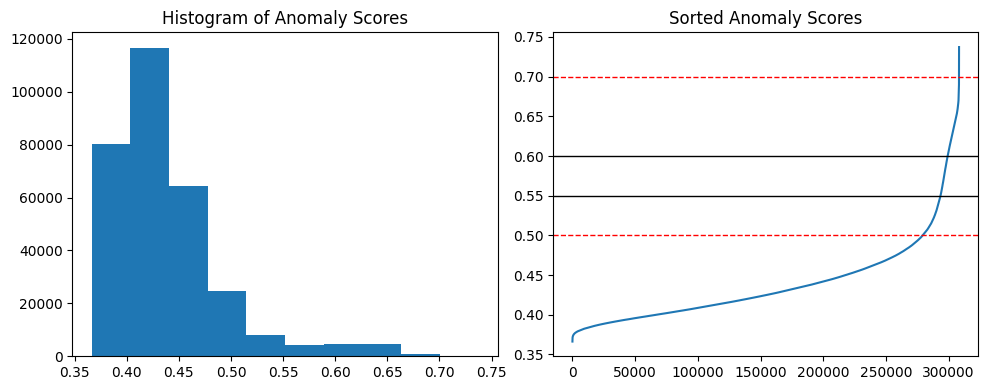

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(scores_df["anomaly_score"])
axes[0].set_title("Histogram of Anomaly Scores")

# Right plot: sorted values plot
axes[1].plot(np.sort(scores_df["anomaly_score"]))
axes[1].set_title("Sorted Anomaly Scores")
axes[1].axhline(0.70, linestyle="--", linewidth=1, c="r")
axes[1].axhline(0.60, linewidth=1, c="k")
axes[1].axhline(0.55, linewidth=1, c="k")
axes[1].axhline(0.50, linestyle="--", linewidth=1, c="r")

plt.tight_layout()
plt.show()

In [4]:
station = "KARAT"
with open(f"../output/backup/ref_segment_dtw_dists_{station}.pkl", "rb") as f:
    info = pickle.load(f)

# with open(f'../scripts/dtw_results.pkl', "rb") as f:
#         info = pickle.load(f)

karat_catalogue = pd.read_csv("../catalogs/DK/KARAT.csv")
karat_catalogue["start"] = [obspy.UTCDateTime(s) for s in karat_catalogue["start"]]
karat_catalogue["stop"] = [obspy.UTCDateTime(s) for s in karat_catalogue["stop"]]

if_segments = pd.read_csv(f"../output/DK/if/segments/{station}.csv", index_col=0)
if_segments["start"] = [obspy.UTCDateTime(i) for i in if_segments["start"]]
if_segments["stop"] = [obspy.UTCDateTime(i) for i in if_segments["stop"]]

In [5]:
X = np.zeros((len(info[1]), len(info[1][0])))
for i in range(len(info[1])):
    X[i] = np.array([np.median(info[1][i][k][0]) for k in range(len(info[1][i]))])

In [7]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(n_estimators=1000)

In [8]:
model.fit(X[50:, :])

IsolationForest(n_estimators=1000)

In [ ]:
leaf_indices = np.zeros((X.shape[0], 1000), dtype=int)

# get leaf node indices for each tree
for t, tree in enumerate(model.estimators_):
    leaf_indices[:, t] = tree.apply(X)


def shared_leaf_proportion(leaf_indices, i, j):
    return np.mean(leaf_indices[i, :] == leaf_indices[j, :])


K = np.zeros((X.shape[0], X.shape[0]))
for i in range(X.shape[0]):
    for j in range(i, X.shape[0]):
        K[i, j] = shared_leaf_proportion(leaf_indices, i, j)
        K[j, i] = K[i, j]

D = np.sqrt(2 * (1 - K))

In [ ]:
from scipy.spatial.distance import squareform

condensed_dist = squareform(D, checks=False)

from scipy.cluster.hierarchy import linkage

# 'average' linkage is common; you can also try 'complete' or 'single'
Z = linkage(condensed_dist, method="ward")

In [269]:
labels = np.repeat(" ", X.shape[0])
labels[:50] = np.arange(50)
cal_idx = np.where(karat_catalogue["labels"] == "CAL")[0]
labels[cal_idx] = "cal"

teq_idx = np.where(karat_catalogue["labels"] == "TEQ")[0]
labels[teq_idx] = "teq"


req_idx = np.where(karat_catalogue["labels"] == "REQ")[0]
labels[teq_idx] = "req"

hel_idx = np.where(karat_catalogue["labels"] == "HEL")[0]
labels[hel_idx] = "hel"

ins_idx = np.where(karat_catalogue["labels"] == "IN")[0]

In [15]:
labels[:50] = karat_catalogue["labels"]

In [92]:
import numpy as np
from scipy.cluster.hierarchy import to_tree


def smallest_cluster_containing(Z, idx):
    n = Z.shape[0] + 1
    idx = set(idx)

    root, nodes = to_tree(Z, rd=True)

    best_node = None

    def get_leaves(node):
        if node.is_leaf():
            return {node.id}
        return get_leaves(node.left) | get_leaves(node.right)

    for node in nodes:
        leaves = get_leaves(node)
        if idx.issubset(leaves):
            if best_node is None or len(leaves) < len(get_leaves(best_node)):
                best_node = node

    return get_leaves(best_node), best_node.dist

In [93]:
idx = np.where(clusters == 13)[0]

In [94]:
cluster_leaves, height = smallest_cluster_containing(Z, idx)
print("Cluster members:", cluster_leaves)
print("Merge height:", height)

Cluster members: {577, 258, 66, 324, 322, 72, 73, 74, 10, 12, 334, 78, 142, 92, 224, 99, 37, 38, 39, 107, 109, 63, 52, 373, 125, 255}
Merge height: 1.7640185765636194


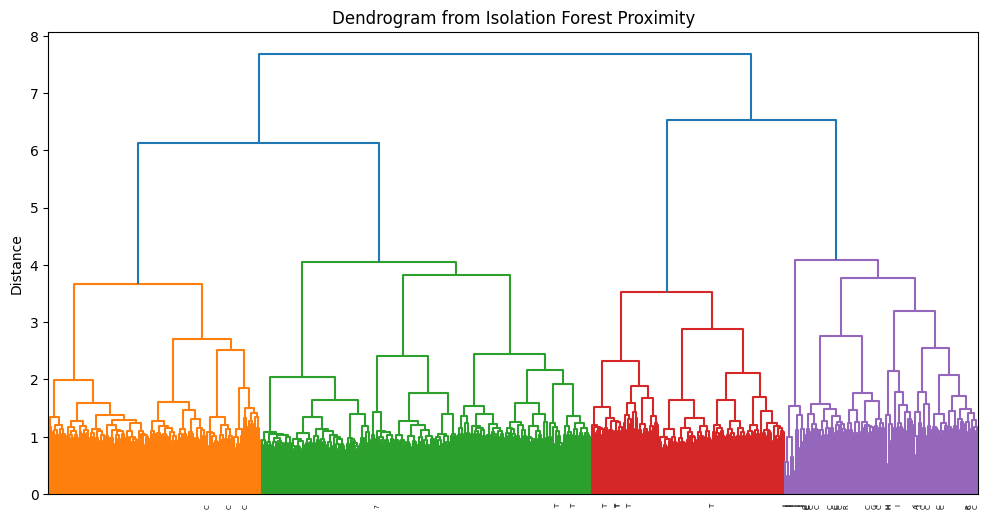

In [17]:
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=labels)  # <-- disables leaf labels
plt.title("Dendrogram from Isolation Forest Proximity")
plt.ylabel("Distance")
plt.show()

In [97]:
def smallest_cluster_node(Z, idx):
    idx = set(idx)
    root, nodes = to_tree(Z, rd=True)

    def leaves(node):
        if node.is_leaf():
            return {node.id}
        return leaves(node.left) | leaves(node.right)

    best = None
    best_leaves = None

    for node in nodes:
        L = leaves(node)
        if idx.issubset(L):
            if best is None or len(L) < len(best_leaves):
                best = node
                best_leaves = L

    return best, best_leaves

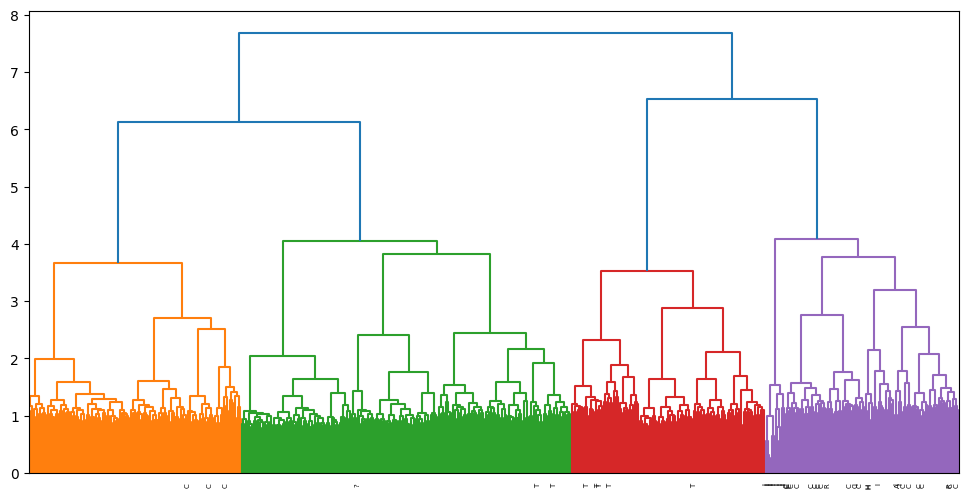

In [100]:
fig, ax = plt.subplots(figsize=(12, 6))

ddata = dendrogram(Z, labels=labels, ax=ax)

node, cluster_leaves = smallest_cluster_node(Z, idx)
height = node.dist

leaf_order = ddata["leaves"]

pos = {leaf: i for i, leaf in enumerate(leaf_order)}

xs = [pos[i] for i in cluster_leaves]

xmin = min(xs)
xmax = max(xs)

xmin_plot = 5 + 10 * xmin
xmax_plot = 5 + 10 * xmax

In [358]:
idx = np.where(clusters == 11)[0]

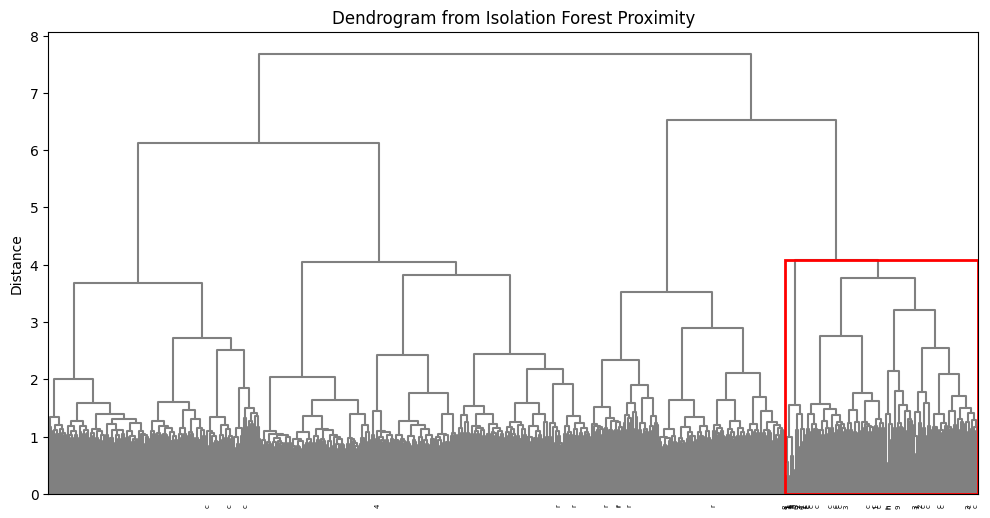

In [359]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from scipy.cluster.hierarchy import dendrogram, to_tree


def smallest_cluster_node(Z, idx):
    idx = set(idx)
    root, nodes = to_tree(Z, rd=True)

    def get_leaves(node):
        if node.is_leaf():
            return {node.id}
        return get_leaves(node.left) | get_leaves(node.right)

    best = None
    best_leaves = None

    for node in nodes:
        leaves = get_leaves(node)
        if idx.issubset(leaves):
            if best is None or len(leaves) < len(best_leaves):
                best = node
                best_leaves = leaves

    return best, best_leaves


fig, ax = plt.subplots(figsize=(12, 6))

# draw dendrogram
ddata = dendrogram(
    Z, labels=labels, ax=ax, color_threshold=0, above_threshold_color="gray"
)

# find minimal cluster containing idx
node, cluster_leaves = smallest_cluster_node(Z, idx)
height = node.dist

# map leaf index -> x coordinate in plot
leaf_order = ddata["leaves"]
leaf_x = {leaf: 5 + 10 * i for i, leaf in enumerate(leaf_order)}

xs = [leaf_x[i] for i in cluster_leaves]
xmin = min(xs)
xmax = max(xs)


rect = patches.Rectangle(
    (xmin - 5, 0),
    (xmax - xmin) + 10,
    height,
    linewidth=2,
    edgecolor="red",
    facecolor="none",
    zorder=10,  # draw above dendrogram
)

ax.add_patch(rect)

ax.set_title("Dendrogram from Isolation Forest Proximity")
ax.set_ylabel("Distance")

plt.show()

In [51]:
# distM = squareform(pdist(X, metric='euclidean'))

clusters = cutreeHybrid(Z, D, minClusterSize=20, deepSplit=1)

clusters = clusters["labels"]

..cutHeight not given, setting it to 7.614463936270675  ===>  99% of the (truncated) height range in dendro.
..done.


In [274]:
np.unique(clusters[ins_idx])

array([ 7, 11], dtype=int64)

In [106]:
np.unique(clusters[cal_idx])

array([ 7, 10, 12, 13], dtype=int64)

In [54]:
clusters[req_idx]

array([ 7, 13], dtype=int64)

In [74]:
clusters[teq_idx]

array([6, 6, 6, 6, 1, 1, 5], dtype=int64)

In [91]:
# for c in np.unique(clusters[cal_idx]):
#     print(np.where(clusters == c))

for c in np.unique(clusters[req_idx]):
    print(np.where(clusters == c)[0])

[  3  16  17  18  26  35  40  41  43  45  53  67  77  86  87 106 119 131
 141 153 156 170 178 191 219 237 262 303 333 349 363 364 432 436 446 451
 475 497 499 515 560 567 605 633]
[ 10  12  37  38  39  52  63  66  72  73  74  78  92  99 107 109 125 142
 224 255 258 322 324 334 373 577]


In [25]:
segments = if_segments.reset_index(drop=True)

folder = "../data/DK/2022/KARAT/HHZ.D/"
stream_paths = [folder + f for f in os.listdir(folder) if not f.startswith("._")]
stream_paths = np.array(sorted(stream_paths, key=lambda f: int(f.rsplit(".", 1)[-1])))

folder = "../data/DK/2023/KARAT/HHZ.D/"
pp = [folder + f for f in os.listdir(folder) if not f.startswith("._")]
pp = np.array(sorted(pp, key=lambda f: int(f.rsplit(".", 1)[-1])))

stream_paths = np.append(stream_paths, pp)

In [330]:
idx

array([ 24,  27,  30,  80,  81,  94, 112, 129, 140, 205, 208, 227, 240,
       242, 250, 261, 287, 295, 296, 313, 318, 325, 357, 359, 362, 379,
       396, 442, 471, 503, 514, 520, 525, 578, 587, 613, 629], dtype=int64)

In [347]:
i = 613
print(segments.iloc[i])

start             2022-09-26T03:49:28.385000Z
stop              2022-09-26T03:51:58.385000Z
scores                               0.600566
control_scores                       0.481928
Name: 613, dtype: object


In [348]:
lag = 300
st = obspy.read(
    find_date_in_strings(stream_paths, str(segments["stop"].iloc[i])[:10])[0]
)
preproc_stream(st)
st.trim(
    segments["start"].iloc[i] - pd.Timedelta(seconds=lag),
    segments["stop"].iloc[i] + pd.Timedelta(seconds=lag),
)

3 Trace(s) in Stream:
DK.KARAT..HHZ | 2022-09-26T03:44:28.395000Z - 2022-09-26T03:45:17.745000Z | 100.0 Hz, 4936 samples
DK.KARAT..HHZ | 2022-09-26T03:45:18.385000Z - 2022-09-26T03:52:43.775000Z | 100.0 Hz, 44540 samples
DK.KARAT..HHZ | 2022-09-26T03:52:44.415000Z - 2022-09-26T03:56:58.395000Z | 100.0 Hz, 25399 samples

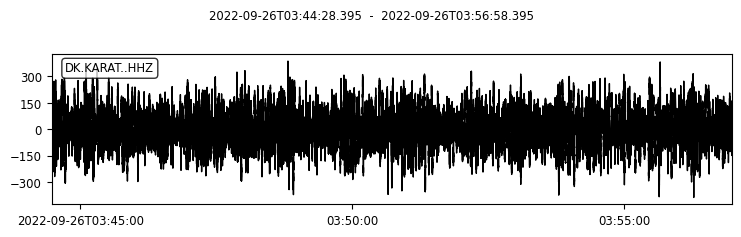

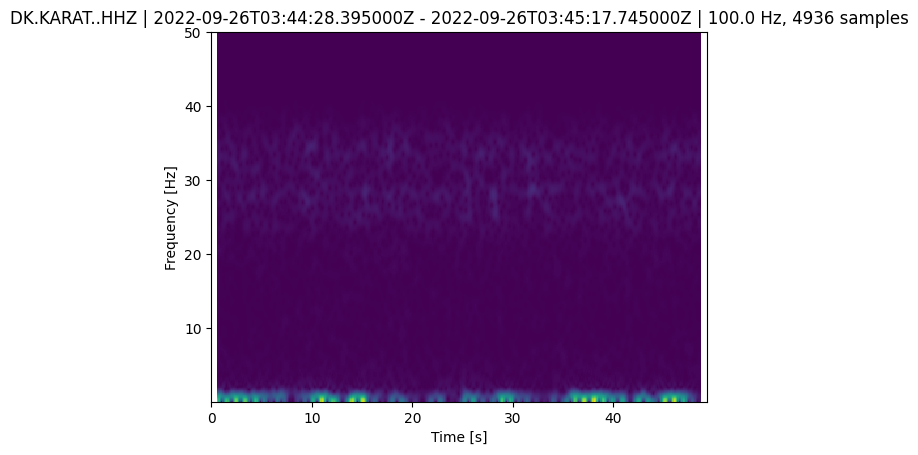

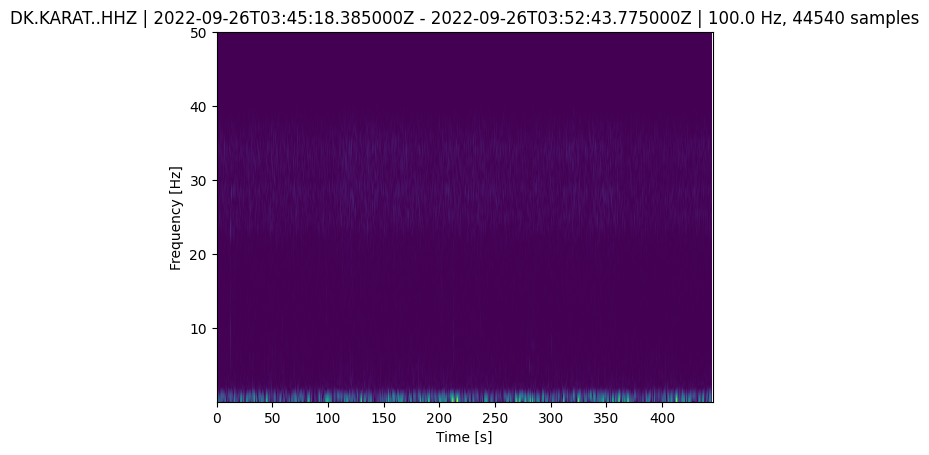

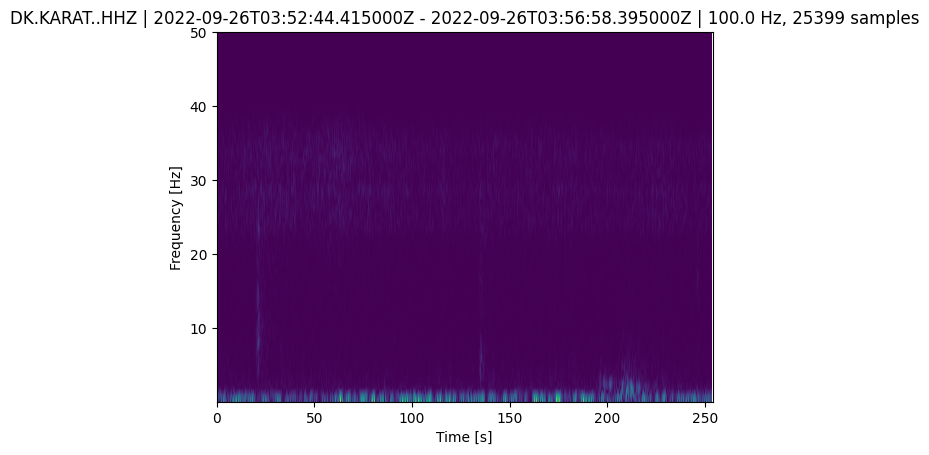

In [349]:
st.plot()
st.spectrogram()
plt.show()

In [4]:
X = np.zeros((len(info[1]), len(info[1][0])))
for i in range(len(info[1])):
    X[i] = np.array([np.median(info[1][i][k][0]) for k in range(len(info[1][i]))])

X[X == 0] = np.nan
X = np.hstack([X, np.array(if_segments[["scores", "control_scores"]])])
X[X == -np.inf] = np.nan
# X = X[50:,:]


mean = np.nanmean(X, axis=0)
std = np.nanstd(X, axis=0, ddof=0)

X = (X - mean) / std

In [5]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(
    n_neighbors=5,  # number of neighbors
    weights="uniform",  # or "distance"
)

X = imputer.fit_transform(X)

In [6]:
Z = linkage(X, method="ward")
distM = squareform(pdist(X, metric="euclidean"))

clusters = cutreeHybrid(Z, distM, minClusterSize=5, deepSplit=3)

clusters = clusters["labels"]

..cutHeight not given, setting it to 182.7037681287591  ===>  99% of the (truncated) height range in dendro.
..done.


In [38]:
# sc = np.array(if_segments["control_scores"])

In [7]:
# labs = np.repeat('',X.shape[0])


# labs[:50] = karat_catalogue["labels"]

# for i in range(X.shape[0]):
#       if sc[i] > 0.60:
#             labs[i] += '*'

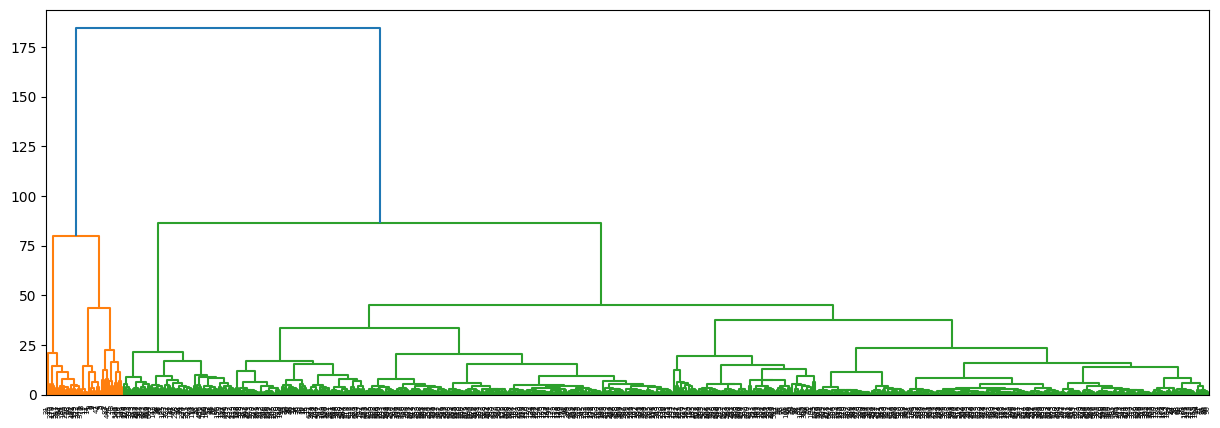

[17 17 18 17 18 18 18 18 18 18 14 18 14 18 18 14 17 12 17 14  3 13 14  3
  8  3 17  8 14 13 14  3  3 14 14 12 14 11 11 14 12 12 18 11 14 12 14  8
  8  3  3  3 11 12  3  3  8  3  8  3  8  3  3 11 13  3 12 12 13 13  3  8
 11  9 11  8  8 11 11 14  8 11 17  8  8 13 12 12  2  8  8  1 11  1  4  8
 14  1  1 11  8  3  3  8  3  1 12 11  8 12 16  8 11 11  8  8  8 16  1 12
  1  3 16  8  1 11  1  1  1 10  1 17 13  1  1  1  8 16 10  1 10 17 11  5
  9  1  3  1  6  1  8  4  2 15  3  8 12  1  1 13  3  1  1  3  2  3  1  1
  1  9 12  8  1  1 13  1  7  9 15  1  2  1  2  1  8 16 10 16  1  2  8 12
  4  1  1 13  1 16  1  9  1  3  1  1  1 10  5  2 10  4  5  1  2  6  2  3
  1  2  5 15  5  4  1  5 11 16  4 10  1  1  1  1  2  1  2  8  4 12  2  3
 10  9 10 13  4  1  1  5  1  1 10  2  3  1  5 11 13 16 11  1  4 10 15  1
  6  1  7  4  1  4 13  2  1  4  2  2  5  4  5  4  5  2  9  6  2  1  6  1
  1  2  5 13  5  2  5 10 10  1  2  4  3  3  3 15  9  2  2  2  1  7  5  4
  5 10  4  2  1  4 10  4  5  5 11  6 11  9  3  4  4

In [8]:
plt.figure(figsize=(15, 5))

dendrogram(Z)

plt.savefig(f"{station}_dendrogram_clusters.png")
plt.show()

print(clusters)

In [351]:
np.where(clusters == 12)[0]

array([ 17,  35,  40,  41,  45,  53,  66,  67,  86,  87, 106, 109, 119,
       156, 170, 191, 237, 432, 436, 446, 451, 475, 633], dtype=int64)

start             2023-07-27T06:56:40.000000Z
stop              2023-07-27T07:06:40.000000Z
scores                               0.722644
control_scores                       0.712333
Name: 17, dtype: object


In [359]:
lag = 300
st = obspy.read(
    find_date_in_strings(stream_paths, str(segments["stop"].iloc[i])[:10])[0]
)
preproc_stream(st)
st.trim(
    segments["start"].iloc[i] - pd.Timedelta(seconds=lag),
    segments["stop"].iloc[i] + pd.Timedelta(seconds=lag),
)

1 Trace(s) in Stream:
DK.KARAT..HHZ | 2022-11-17T11:55:18.390000Z - 2022-11-17T12:08:38.390000Z | 100.0 Hz, 80001 samples

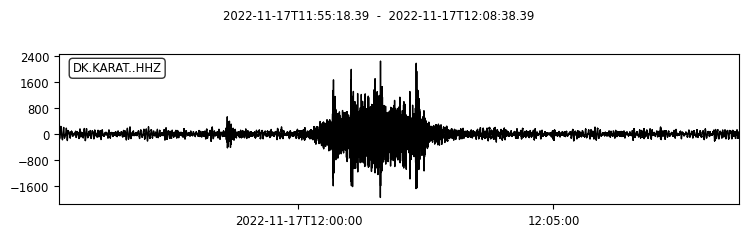

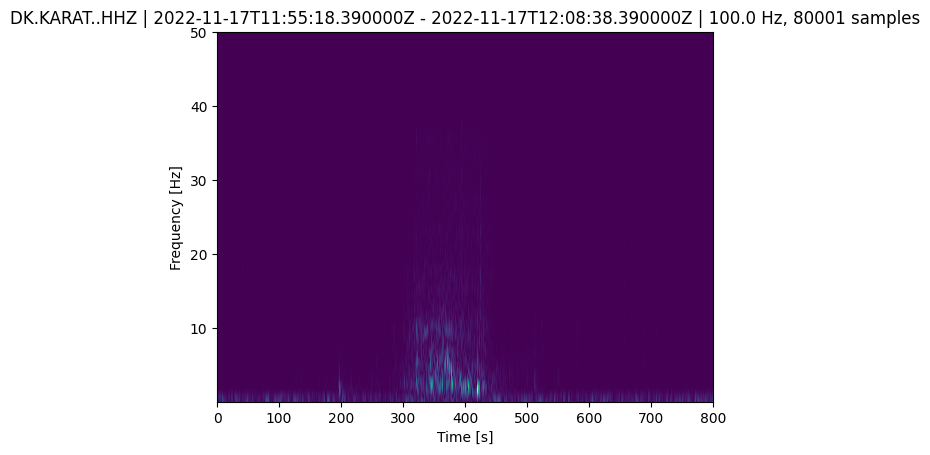

In [360]:
st.plot()
st.spectrogram()
plt.show()

In [ ]:
# 3 = TEQ
# 4 = C + REQ
# 5 = TEQ
# 6 = C + REQ
# 7 = H
# 8 = Noise
# 9 = TEQ
# 10 = Noise + c

In [113]:
segments = if_segments

In [192]:
if_segments[clusters == 3].iloc[30:40, :]

,start,stop,scores,control_scores
301,2023-05-20T02:09:52.320000Z,2023-05-20T02:13:12.320000Z,0.617731,0.629423
302,2022-12-16T01:44:10.000000Z,2022-12-16T01:51:40.000000Z,0.617612,0.639616
326,2022-12-04T11:18:22.440000Z,2022-12-04T11:20:52.440000Z,0.615196,0.573432
341,2023-03-28T09:29:10.000000Z,2023-03-28T09:31:40.000000Z,0.613514,0.583234
383,2022-10-18T16:28:15.350000Z,2022-10-18T16:32:25.350000Z,0.610883,0.561533
401,2022-10-14T22:53:15.350000Z,2022-10-14T22:58:15.350000Z,0.609643,0.497103
403,2023-05-26T10:14:02.320000Z,2023-05-26T10:16:32.320000Z,0.609582,0.581034
408,2022-10-20T12:07:25.350000Z,2022-10-20T12:10:45.350000Z,0.609259,0.616855
412,2023-09-05T12:26:40.000000Z,2023-09-05T12:31:40.000000Z,0.609010,0.523053
423,2023-09-05T12:03:20.000000Z,2023-09-05T12:05:50.000000Z,0.608566,0.516937


In [193]:
i = 423

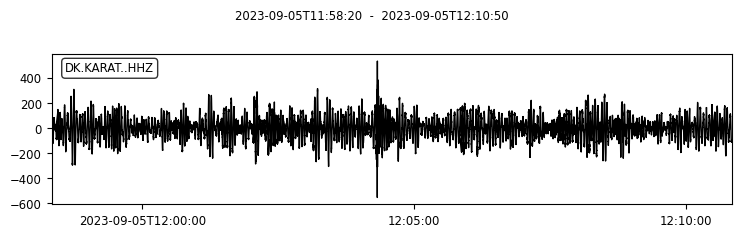

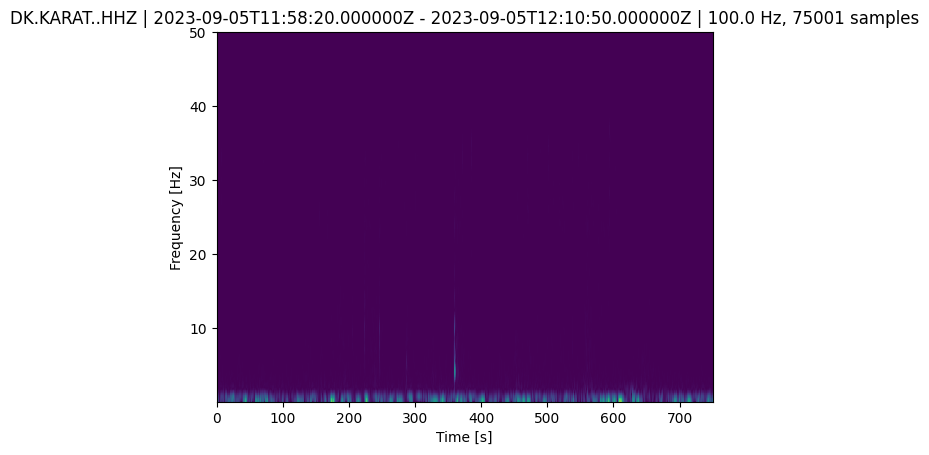

In [194]:
st = obspy.read(
    find_date_in_strings(stream_paths, str(if_segments["stop"].iloc[i])[:10])[0]
)
preproc_stream(st)
st.trim(
    if_segments["start"].iloc[i] - pd.Timedelta(seconds=300),
    if_segments["stop"].iloc[i] + pd.Timedelta(seconds=300),
)


st.plot()
plt.show()
st.spectrogram()
plt.show()

In [73]:
folder = "../data/XP/2020/ILL18/EHZ.D/"
stream_paths = [folder + f for f in os.listdir(folder) if not f.startswith("._")]
stream_paths = np.array(sorted(stream_paths, key=lambda f: int(f.rsplit(".", 1)[-1])))

# folder = "../data/DK/2023/KARAT/HHZ.D/"
# pp = [folder + f for f in os.listdir(folder) if not f.startswith("._")]
# pp = np.array(sorted(pp, key=lambda f: int(f.rsplit(".", 1)[-1])))

# stream_paths = np.append(stream_paths, pp)

In [74]:
t0 = obspy.UTCDateTime("2020-09-29T07:00:00.000000")
t1 = obspy.UTCDateTime("2020-09-29T13:00:00.000000")

In [75]:
st = obspy.read(find_date_in_strings(stream_paths, "2020-09-29")[0])
preproc_stream(st)
st.trim(t0, t1)

1 Trace(s) in Stream:
XP.ILL18..EHZ | 2020-09-29T07:00:00.000000Z - 2020-09-29T13:00:00.000000Z | 100.0 Hz, 2160001 samples

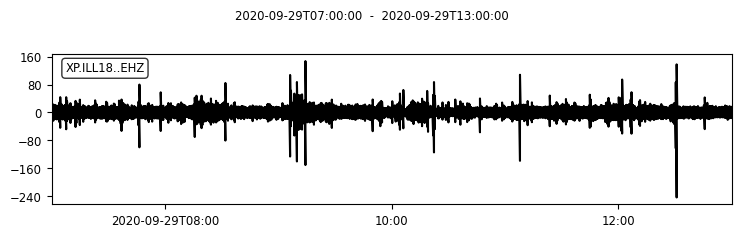

In [76]:
st.plot()
plt.show()

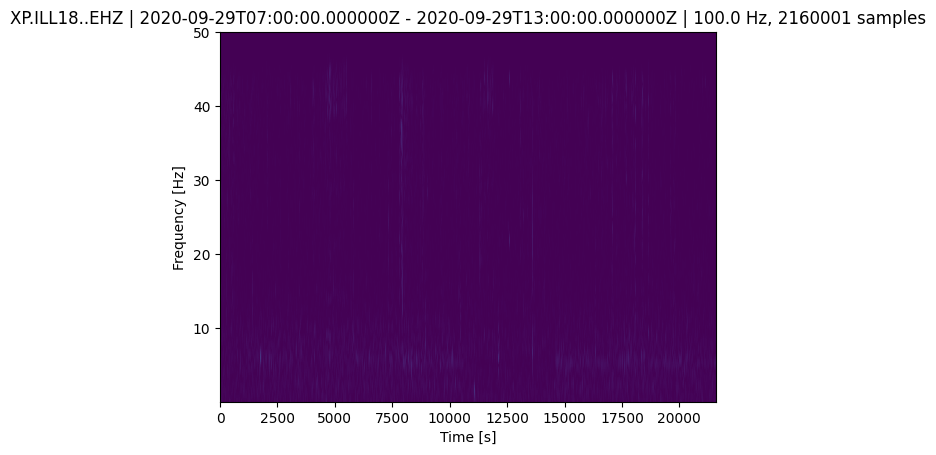

[None]

In [77]:
st.spectrogram()

In [130]:
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.metrics import silhouette_score

silhouette_scores = []
Z = linkage(X, method="ward")
# Try different numbers of clusters
for k in range(2, 20):  # reasonable range
    labels = fcluster(Z, t=k, criterion="maxclust")
    score = silhouette_score(X, labels)
    silhouette_scores.append((k, score))
    print(f"k={k}, silhouette={score:.4f}")

# Find best k
best_k, best_score = max(silhouette_scores, key=lambda x: x[1])
print(f"\nOptimal number of clusters = {best_k} (silhouette = {best_score:.4f})")

k=2, silhouette=0.8510
k=3, silhouette=0.5363
k=4, silhouette=0.4322
k=5, silhouette=0.3146
k=6, silhouette=0.2165
k=7, silhouette=0.2163
k=8, silhouette=0.1940
k=9, silhouette=0.2013
k=10, silhouette=0.2029
k=11, silhouette=0.1946
k=12, silhouette=0.1895
k=13, silhouette=0.1943
k=14, silhouette=0.1941
k=15, silhouette=0.1966
k=16, silhouette=0.1998
k=17, silhouette=0.1956
k=18, silhouette=0.1958
k=19, silhouette=0.1910

Optimal number of clusters = 2 (silhouette = 0.8510)


In [10]:
from sklearn.metrics import calinski_harabasz_score, davies_bouldin_score

Z = linkage(X[50:, :], method="ward")

results = []

for k in range(2, 11):
    labels = fcluster(Z, t=k, criterion="maxclust")
    ch = calinski_harabasz_score(X[50:, :], labels)
    db = davies_bouldin_score(X[50:, :], labels)
    results.append((k, ch, db))
    print(f"k={k}: CH={ch:.2f}, DB={db:.2f}")

k=2: CH=1194.34, DB=0.21
k=3: CH=1174.81, DB=0.76
k=4: CH=994.57, DB=0.88
k=5: CH=865.45, DB=1.08
k=6: CH=783.83, DB=1.25
k=7: CH=722.82, DB=1.28
k=8: CH=671.36, DB=1.29
k=9: CH=621.50, DB=1.36
k=10: CH=583.79, DB=1.27


k=2, silhouette=0.8510
k=3, silhouette=0.6957
k=4, silhouette=0.5606
k=5, silhouette=0.5451
k=6, silhouette=0.5368
k=7, silhouette=0.4916
k=8, silhouette=0.4843
k=9, silhouette=0.4104
k=10, silhouette=0.4029
k=11, silhouette=0.2284
k=12, silhouette=0.2278
k=13, silhouette=0.2263
k=14, silhouette=0.2273
k=15, silhouette=0.2058
k=16, silhouette=0.1616
k=17, silhouette=0.1607
k=18, silhouette=0.1602
k=19, silhouette=0.1606

Optimal number of clusters = 2 (silhouette = 0.8510)


In [16]:
clusters = fcluster(Z, t=4, criterion="maxclust")

In [17]:
for c in np.unique(clusters):
    print(f"Cluster {c}: {np.sum(clusters == c)} segments")
# np.sum(clusters == 4)

Cluster 1: 18 segments
Cluster 2: 5 segments
Cluster 3: 492 segments
Cluster 4: 69 segments


In [16]:
classes = np.unique(labs)

In [32]:
D = Dw[np.ix_(known_label_idx, known_label_idx)]

In [35]:
F = []
for i in range(50, Dw.shape[0]):
    d = Dw[i, known_label_idx]
    Dn = np.hstack([D, d.reshape(-1, 1)])
    Dn = np.vstack([Dn, np.append(d, 0)])

    sqf = squareform(Dn)
    Z = linkage(sqf, method="complete")
    hh = get_merge_height(Z, Dn.shape[0] - 1)

    # clusters = fcluster(Z, t=hh, criterion='distance')
    # members = labs[clusters[:-1] == clusters[-1]]

    # class_prop = np.zeros(len(classes))
    # for c in range(len(classes)):
    #     class_prop[c] = np.mean(members == classes[c])

    # F.append(np.append(class_prop,hh))
    F.append(hh)
F = np.array(F)

{'whiskers': [<matplotlib.lines.Line2D at 0x221ca40ab00>,
 'caps': [<matplotlib.lines.Line2D at 0x221ca40b040>,
 'boxes': [<matplotlib.lines.Line2D at 0x221ca40a860>],
 'medians': [<matplotlib.lines.Line2D at 0x221ca40b580>],
 'fliers': [<matplotlib.lines.Line2D at 0x221ca40b820>],
 'means': []}

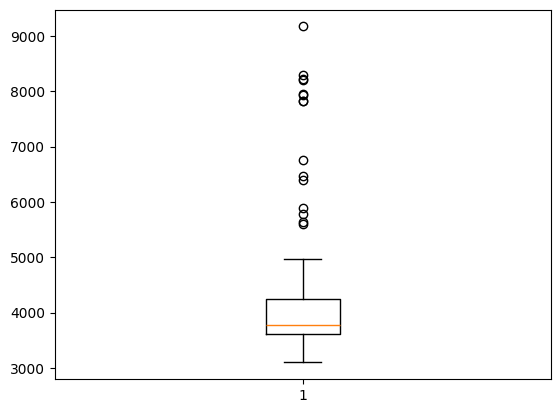

In [37]:
plt.boxplot(F)

In [70]:
Q1 = np.percentile(F, 25)
Q3 = np.percentile(F, 75)
IQR = Q3 - Q1
cut_value = Q3 + 1.5 * IQR

In [71]:
cut_value

5199.5461754315

In [72]:
50 + np.where(F > cut_value)[0]

array([ 64,  68,  69,  82,  85, 132, 138, 141, 153, 159, 174, 186, 191,
       195, 197], dtype=int64)

In [21]:
np.where(clusters == 1)[0] + 50

array([ 64,  68,  69,  82,  85, 132, 159, 174, 195, 243, 256, 270, 291,
       372, 375, 397, 491, 517], dtype=int64)

In [22]:
np.where(clusters == 2)[0] + 50

array([131, 141, 349, 441, 560], dtype=int64)

In [31]:
# np.where(clusters == 3)[0] + 50

In [24]:
np.where(clusters == 4)[0] + 50

array([ 52,  53,  63,  66,  67,  72,  74,  77,  78,  81,  86,  87,  92,
        99, 106, 107, 109, 112, 113, 119, 125, 137, 138, 142, 153, 156,
       170, 178, 186, 191, 219, 224, 225, 237, 255, 258, 262, 303, 313,
       322, 324, 325, 333, 334, 363, 364, 373, 427, 432, 436, 442, 446,
       451, 475, 488, 497, 499, 515, 525, 543, 553, 567, 577, 587, 596,
       605, 621, 629, 633], dtype=int64)

In [68]:
i = 74
if_segments.iloc[i]

start             2023-09-09T19:50:50.000000Z
stop              2023-09-09T19:55:50.000000Z
scores                               0.659933
control_scores                       0.419662
Name: 74, dtype: object

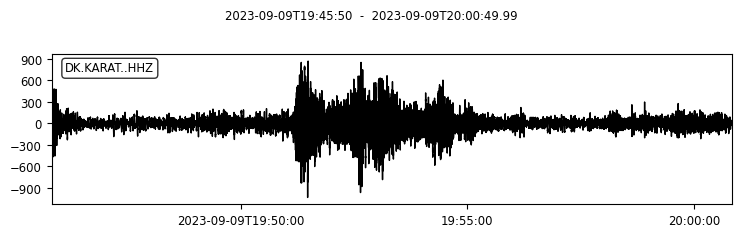

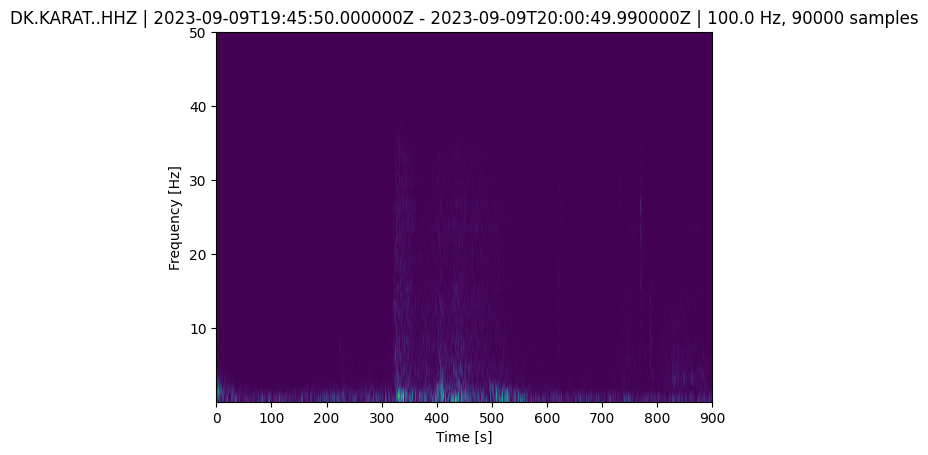

In [ ]:
all_idx = np.concatenate([massm, eqs, noise])


def compute_pvals(idx):
    Dcal = Dw[np.ix_(idx, idx)]
    sqf = squareform(Dcal)
    Z = linkage(sqf, method="complete")
    cal_heights = np.array([get_merge_height(Z, i) for i in range(Dcal.shape[0])])

    pvals = []
    for i in range(50, Dw.shape[0]):
        d = Dw[i, idx]
        repl_heights = []
        for i in range(Dcal.shape[0]):
            D = Dcal.copy()
            D[:, i] = d
            D[i, :] = d
            D[i, i] = 0
            sqf = squareform(D)
            Z = linkage(sqf, method="complete")
            repl_heights.append(get_merge_height(Z, i))
        repl_heights = np.array(repl_heights)
        pvals.append(np.mean(repl_heights < cal_heights))

    return np.array(pvals)

In [ ]:
def compute_pvals(idx):
    Dcal = Dw[np.ix_(idx, idx)]
    sqf = squareform(Dcal)
    Z = linkage(sqf, method="complete")
    cal_heights = np.array([get_merge_height(Z, i) for i in range(Dcal.shape[0])])

    pvals = []
    for i in range(50, Dw.shape[0]):
        d = Dw[i, idx]
        repl_heights = []
        for i in range(Dcal.shape[0]):
            D = Dcal.copy()
            D[:, i] = d
            D[i, :] = d
            D[i, i] = 0
            sqf = squareform(D)
            Z = linkage(sqf, method="complete")
            repl_heights.append(get_merge_height(Z, i))
        repl_heights = np.array(repl_heights)
        pvals.append(np.mean(repl_heights < cal_heights))

    return np.array(pvals)

In [30]:
X = np.hstack(
    [
        compute_pvals(massm).reshape(-1, 1),
        compute_pvals(eqs).reshape(-1, 1),
        compute_pvals(noise).reshape(-1, 1),
        compute_pvals(all_idx).reshape(-1, 1),
    ]
)

In [16]:
X.shape

(150, 4)

In [32]:
X = np.hstack(
    [
        X,
        if_segments["scores"].values[50:200].reshape(-1, 1),
        if_segments["control_scores"].values[50:200].reshape(-1, 1),
    ]
)

In [33]:
X = X[~np.any(X == -np.inf, axis=1), :]

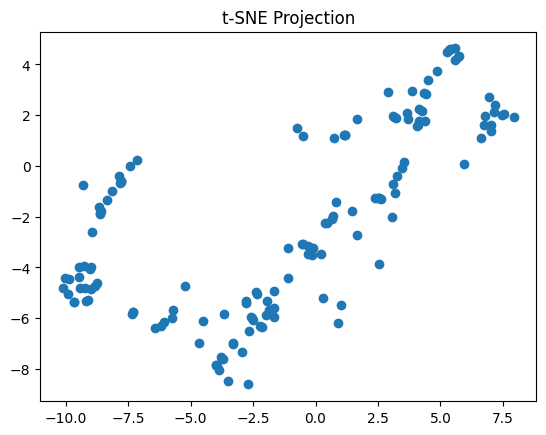

In [34]:
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Example: X should be your data matrix of shape (n_samples, n_features)
# X = np.load('your_matrix.npy')  # or however you load your data

# Create t-SNE model
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)

# Fit and transform
X_embedded = tsne.fit_transform(X)

# Plot result
plt.scatter(X_embedded[:, 0], X_embedded[:, 1])
# plt.scatter(X_embedded[massm, 0], X_embedded[massm, 1], label='Mass Movements',c="k")
# plt.scatter(X_embedded[eqs, 0], X_embedded[eqs, 1], label='Earthquakes',c="r")
# plt.scatter(X_embedded[noise, 0], X_embedded[noise, 1], label='Noise',c="b")
plt.title("t-SNE Projection")
plt.show()

In [53]:
np.where((X_embedded[:, 0] > 6) & (X_embedded[:, 1] > 0))

(array([  3,  49,  79,  80,  89, 101, 118, 126, 133, 139, 145], dtype=int64),)

In [54]:
X_embedded[3, :]

array([6.772392 , 1.9574821], dtype=float32)

In [ ]:
station = "ILL11"

In [62]:
station = "ILL12"

In [63]:
with open(f"../output/backup/ref_segment_dtw_dists_{station}.pkl", "rb") as f:
    info = pickle.load(f)
unknown_segments = info[0]

X = np.zeros((len(info[1]), len(info[1][0])))
for i in range(len(info[1])):
    X[i] = np.array([np.median(info[1][i][k][0]) for k in range(len(info[1][i]))])

In [64]:
with open(f"../output/backup//tr_high_conf_pair_dtw_dists{station}.pkl", "rb") as f:
    info = pickle.load(f)

In [65]:
nseg = max(info[0])[1] + 1
D = np.zeros([nseg, nseg])

for k in range(len(info[0])):
    i, j = info[0][k]
    D[i, j] = np.median(info[1][k][0])
    D[j, i] = D[i, j]

In [66]:
# def get_merge_height(Z, obj_index):
#     """
#     Returns the first height at which the object with index `obj_index`
#     is merged into any cluster.
#     """
#     for row in Z:
#         if obj_index in row[:2]:
#             return row[2]
#     return None

# def remove_singleton_merges(D):
#     nseg = D.shape[0]
#     Dsqf = squareform(D)
#     Z = linkage(Dsqf, method='complete')

#     max_merge_height = np.max(Z[:, 2])
#     merge_heights = np.array([get_merge_height(Z, i) for i in range(nseg)])

#     idx = np.arange(nseg)
#     while np.max(merge_heights) == max_merge_height:
#         idx = np.array(idx[idx != idx[np.argmax(merge_heights)]])
#         Dr = D[np.ix_(idx, idx)]
#         Dsqf = squareform(Dr)
#         Z = linkage(Dsqf, method='complete')
#         merge_heights = np.array([get_merge_height(Z, i) for i in range(len(idx))])
#         max_merge_height = np.max(Z[:, 2])

#     return idx

In [67]:
min_len = 300

In [68]:
idx = remove_singleton_merges(D)
Dr = D[np.ix_(idx, idx)]

In [69]:
dtw_segments = pd.read_csv(f"../output/XP/if/segments/{station}.csv").iloc[:, 1:]
dtw_segments["start"] = [obspy.UTCDateTime(i) for i in dtw_segments["start"]]
dtw_segments["stop"] = [obspy.UTCDateTime(i) for i in dtw_segments["stop"]]
lens = np.array(dtw_segments["stop"] - dtw_segments["start"], dtype=float)
dtw_segments = dtw_segments[lens > min_len].reset_index(drop=True)

In [70]:
dtw_segments.shape

(246, 3)

In [71]:
scores = []
for i in range(dtw_segments.shape[0]):
    x = X[i, idx]
    non_zero_idx = np.where(x != 0)[0]
    x = x[non_zero_idx]

    Dn = Dr[np.ix_(non_zero_idx, non_zero_idx)]
    Dn = np.hstack([Dn, x.reshape(-1, 1)])
    Dn = np.vstack([Dn, np.append(x, 0)])

    Dsqf = squareform(Dn)
    Z = linkage(Dsqf, method="complete")

    scores.append(get_merge_height(Z, Dn.shape[0] - 1))


dtw_segments["scores"] = scores
dtw_segments = dtw_segments.sort_values("scores").reset_index(drop=True)

In [72]:
dtw_segments

,start,stop,scores
0,2021-07-16T03:43:42.770000Z,2021-07-16T05:29:32.770000Z,6293.037524
1,2020-08-16T21:37:33.410000Z,2020-08-16T22:27:33.410000Z,6311.275766
2,2020-06-17T03:35:42.920000Z,2020-06-17T04:43:12.920000Z,6338.468032
3,2020-06-29T04:56:10.630000Z,2020-06-29T05:55:20.630000Z,6358.435431
4,2020-06-08T16:54:02.920000Z,2020-06-08T17:43:12.920000Z,6359.099415
...,...,...,...
241,2020-05-13T10:27:50.350000Z,2020-05-13T10:35:20.350000Z,8791.407272
242,2020-05-14T14:06:32.920000Z,2020-05-14T14:20:42.920000Z,9058.219704
243,2019-10-23T07:47:22.660000Z,2019-10-23T08:01:32.660000Z,9076.611381
244,2020-10-01T12:57:22.030000Z,2020-10-01T13:05:42.030000Z,9159.873232


In [73]:
tr_start, tr_stop = 2018, 2020

In [74]:
flows = preproc_flow_annotations(
    pd.read_csv("../catalogs/XP/calibration_catalog.csv", index_col=0)
)
tr_lower_conf_flows, tr_high_conf_flows, _ = extract_split_flows(
    flows, station, tr_start, tr_stop
)
tr_station_flows = pd.concat([tr_lower_conf_flows, tr_high_conf_flows]).reset_index(
    drop=True
)
tr_start_UTC = obspy.UTCDateTime(f"{tr_start}-01-01")
tr_stop_UTC = obspy.UTCDateTime(f"{tr_stop}-12-31T23:59:59.999999")

tr_segments = dtw_segments[
    (dtw_segments["start"] > tr_start_UTC) & (dtw_segments["stop"] < tr_stop_UTC)
].reset_index(drop=True)
valid_segments = extract_valid_segments(
    tr_segments, tr_lower_conf_flows, tr_high_conf_flows
)

best_iou, min_len, score_thres = est_thresholds(
    valid_segments, tr_high_conf_flows, mode="upper"
)


print(f"best iou = {best_iou}, min_len = {min_len}, score_thres = {score_thres}")

best iou = 0.6229817383319809, min_len = 800.0, score_thres = 7145.932419940508


In [96]:
flows = preproc_flow_annotations(
    pd.read_csv("../catalogs/XP/flow_catalog.csv", index_col=0)
)

In [102]:
flows["start"] = flows_fixed["start"].apply(lambda x: str(x))
flows["stop"] = flows_fixed["stop"].apply(lambda x: str(x))

In [103]:
for col in flows.columns:
    try:
        flows[col].apply(hash)
        print(col, "✓ hashable")
    except TypeError:
        print(col, "✗ NOT hashable")

station ✓ hashable
channel ✓ hashable
start ✓ hashable
stop ✓ hashable
confidence ✓ hashable
Notes ✓ hashable


In [98]:
flows["start"].apply(type).value_counts()
flows["stop"].apply(type).value_counts()

stop
<class 'obspy.core.utcdatetime.UTCDateTime'>    460
Name: count, dtype: int64

In [105]:
flows.duplicated().sum()

0

In [244]:
tr_dtc

,start,stop,scores
0,2020-06-04T15:31:01.250000Z,2020-06-04T18:03:31.250000Z,6541.481920
1,2019-07-02T22:27:30.000000Z,2019-07-03T00:10:50.000000Z,6561.909314
2,2019-08-20T16:55:00.000000Z,2019-08-20T18:05:50.000000Z,6625.755209
3,2019-07-26T17:44:10.000000Z,2019-07-26T19:15:50.000000Z,6645.445388
4,2020-06-17T04:13:43.960000Z,2020-06-17T04:24:33.960000Z,6669.294969
5,2019-07-15T04:00:50.000000Z,2019-07-15T05:03:20.000000Z,6701.411576
6,2020-06-29T05:16:02.350000Z,2020-06-29T06:41:52.350000Z,6731.688754
7,2020-06-08T17:40:50.970000Z,2020-06-08T19:00:50.970000Z,6911.446759
8,2020-06-07T09:00:44.660000Z,2020-06-07T09:59:54.660000Z,6938.708278
9,2020-08-30T05:49:29.400000Z,2020-08-30T11:26:59.400000Z,6975.654963


In [ ]:
flows = preproc_flow_annotations(
    pd.read_csv("../catalogs/XP/calibration_catalog.csv", index_col=0)
)
lower_conf_flows, high_conf_flows, _ = extract_split_flows(
    flows, station, tr_start, tr_stop
)

In [1192]:
# station = "ILL17"a

In [1193]:
# X = np.load(f"../output/XP/if_dtw/distances/{station}.npy")

In [1194]:
# unknown_segments = pd.read_csv(f"../output/XP/if/segments/{station}.csv").iloc[:,1:]
# unknown_segments["start"] = [obspy.UTCDateTime(i) for i in unknown_segments["start"]]
# unknown_segments["stop"] = [obspy.UTCDateTime(i) for i in unknown_segments["stop"]]

In [1195]:
# X = []
# for i in range(len(info[0])):
#     X.append(np.array([info[1][i][j][0]/len(info[1][i][j][1]) for j in range(len(info[1][i]))]))
# X = np.array(X)

In [1196]:
# lens = np.array(unknown_segments["stop"] - unknown_segments["start"],dtype=float)
# Z = linkage(X, method='ward')
# flows = preproc_flow_annotations(pd.read_csv("../catalogs/XP/initial_catalog.csv",index_col=0))
# tr_lower_conf_flows, tr_high_conf_flows, _ = extract_split_flows(flows,station,2018,2020)
# tr_station_flows = pd.concat([tr_lower_conf_flows, tr_high_conf_flows]).reset_index(drop=True)
# labs = np.repeat('',X.shape[0])

# for i in range(tr_high_conf_flows.shape[0]):
#     I,_,_ = iou(unknown_segments,tr_high_conf_flows.iloc[[i],:].reset_index(drop=True))
#     idx = np.where(np.append(I[0],np.diff(I)) > 0)[0]
#     if len(idx) == 0:
#         continue
#     idx = idx[np.argmax(lens[idx])]
#     labs[idx] = 'x'

# labeled_idx = np.where(labs == 'x')[0]

# labs = np.array([str(i) for i in np.arange(X.shape[0])])
# for i in range(labs.shape[0]):
#     if i not in labeled_idx:
#         labs[i] = ''

# plt.figure(figsize=(20, 9))
# dendrogram(Z,labels=labs)
# plt.title(f"{station}")
# plt.savefig(f"dendrogram_{station}.png")
# plt.show()

In [1197]:
# from scipy.spatial.distance import pdist, squareform

# _, coph_dists = cophenet(Z, pdist(X))
# coph_matrix = squareform(coph_dists)

# hh = []

# for j in range(X.shape[0]):
#      if j not in labeled_idx:
#         hh.append(np.min(coph_matrix[j, labeled_idx]))
#          #hh.append(first_common_cluster_height(Z, j, labeled_idx))
#      else:
#         other_idx = labeled_idx[labeled_idx != j]
#         #hh.append(first_common_cluster_height(Z, j, other_idx))
#         hh.append(np.min(coph_matrix[j, other_idx]))


# hh = np.array(hh)
# hh = np.mean(X,axis=1)

# plt.boxplot(hh)
# plt.show()


In [1198]:
flows = preproc_flow_annotations(
    pd.read_csv("../catalogs/XP/calibration_catalog.csv", index_col=0)
)
tr_lower_conf_flows, tr_high_conf_flows, _ = extract_split_flows(
    flows, station, 2018, 2020
)
tr_station_flows = pd.concat([tr_lower_conf_flows, tr_high_conf_flows]).reset_index(
    drop=True
)
labs = np.repeat("", X.shape[0])

In [1199]:
dtw_segments = unknown_segments.copy()
dtw_segments["scores"] = hh
dtw_segments = dtw_segments.iloc[np.argsort(hh), :].reset_index(drop=True)
dtw_segments["start"] = [obspy.UTCDateTime(i) for i in dtw_segments["start"]]
dtw_segments["stop"] = [obspy.UTCDateTime(i) for i in dtw_segments["stop"]]

In [238]:
tr_start, tr_stop = 2018, 2020
flows = preproc_flow_annotations(
    pd.read_csv("../catalogs/XP/calibration_catalog.csv", index_col=0)
)
lower_conf_flows, high_conf_flows, _ = extract_split_flows(
    flows, station, tr_start, tr_stop
)
tr_start_UTC = obspy.UTCDateTime(f"{tr_start}-01-01")
tr_stop_UTC = obspy.UTCDateTime(f"{tr_stop}-12-31T23:59:59.999999")
tr_segments = dtw_segments[
    (dtw_segments["start"] > tr_start_UTC) & (dtw_segments["stop"] < tr_stop_UTC)
].reset_index(drop=True)

valid_segments = extract_valid_segments(tr_segments, lower_conf_flows, high_conf_flows)
best_iou, min_len, score_thres = est_thresholds(
    valid_segments, high_conf_flows, mode="upper"
)

print(f"best iou = {best_iou}, min_len = {min_len}, score_thres = {score_thres}")

best iou = 0.6029090531874369, min_len = 600.0, score_thres = 8079.2317690849495


best iou = 0.6244629045047213, min_len = 950.0, score_thres = 7238.002389453945


In [1202]:
lens = np.array(dtw_segments["stop"] - dtw_segments["start"], dtype=float)
dtc = dtw_segments[
    (dtw_segments["scores"] < score_thres) * (lens > min_len)
].reset_index(drop=True)
year = np.array([int(str(i)[:4]) for i in dtc["start"]])
tr_dtc = dtc[year <= 2020].reset_index(drop=True)
te_dtc = dtc[year > 2020].reset_index(drop=True)

Training - DTW - HC {'iou': 61.017962096688116, 'recall': 100.0, 'FN': 0, 'precision': 95.83333333333334, 'FP': 1, 'TP': 23}
Training - DTW - ALL {'iou': 47.89783739442071, 'recall': 97.05882352941177, 'FN': 1, 'precision': 97.05882352941177, 'FP': 1, 'TP': 33}
Testing - DTW - HC {'iou': 71.73992809701925, 'recall': 100.0, 'FN': 0, 'precision': 100.0, 'FP': 0, 'TP': 16}
Testing - DTW - ALL {'iou': 51.63667056960847, 'recall': 90.9090909090909, 'FN': 2, 'precision': 100.0, 'FP': 0, 'TP': 20}


In [861]:
te_high_conf_flows

,station,channel,start,stop,confidence,Notes
0,ILL16,EHZ,2021-06-22T19:41:00.000000Z,2021-06-22T20:16:01.000000Z,high,Not in WSL Observatory.
1,ILL16,EHZ,2021-06-24T15:11:00.000000Z,2021-06-24T15:58:00.000000Z,high,NaN
2,ILL16,EHZ,2021-07-06T18:44:00.000000Z,2021-07-06T19:23:00.000000Z,high,NaN
3,ILL16,EHZ,2021-07-13T14:55:00.000000Z,2021-07-13T17:21:00.000000Z,high,NaN
4,ILL16,EHZ,2021-07-16T03:36:00.000000Z,2021-07-16T04:43:00.000000Z,high,NaN
5,ILL16,EHZ,2021-08-07T14:10:00.000000Z,2021-08-07T15:26:00.000000Z,high,NaN
6,ILL16,EHZ,2021-09-19T05:51:00.000000Z,2021-09-19T07:27:00.000000Z,high,NaN
7,ILL16,EHZ,2022-06-30T20:18:00.000000Z,2022-06-30T21:16:00.000000Z,high,NaN
8,ILL16,EHZ,2022-07-04T21:39:00.000000Z,2022-07-04T22:21:00.000000Z,high,NaN


In [331]:
te_dtc

,start,stop,scores
0,2021-08-07T14:32:51.220000Z,2021-08-07T16:22:01.220000Z,6594.354987
1,2021-07-16T03:55:57.070000Z,2021-07-16T06:34:17.070000Z,6609.177102
2,2021-09-19T06:44:10.760000Z,2021-09-19T07:55:50.760000Z,6702.448276
3,2021-05-21T23:18:55.620000Z,2021-05-22T00:43:05.620000Z,6810.594684
4,2021-06-22T20:07:21.290000Z,2021-06-22T21:39:51.290000Z,6818.996113
5,2021-06-24T15:23:53.980000Z,2021-06-24T17:38:03.980000Z,6849.164371
6,2022-07-04T21:48:51.410000Z,2022-07-04T23:44:41.410000Z,7101.659962
7,2021-07-13T16:11:36.770000Z,2021-07-13T18:44:56.770000Z,7209.159673
8,2021-07-06T18:56:26.060000Z,2021-07-06T20:21:26.060000Z,7220.156631
9,2021-05-11T14:33:55.620000Z,2021-05-11T16:53:05.620000Z,7238.043540


In [330]:
find_fp_fn(te_valid_segments, te_high_conf_flows)[0]

,start,stop,scores
0,2022-07-04T21:48:51.410000Z,2022-07-04T23:44:41.410000Z,7101.659962


In [74]:
find_fp_fn(tr_valid_segments, tr_high_conf_flows)[0]

,start,stop,scores


In [75]:
valid_detections = extract_valid_segments(
    sta_lta_detections, lower_conf_flows, high_conf_flows
)

NameError: name 'sta_lta_detections' is not defined

In [2392]:
h = min_height_for_group(Z, np.where(labs == "x")[0])
cl = fcluster(Z, t=h, criterion="distance")
flow_clusters = np.unique(cl[labs == "x"])
dtc = unknown_segments[np.isin(cl, flow_clusters)].reset_index(drop=True)

In [2393]:
year = np.array([int(str(i)[:4]) for i in dtc["start"]])
tr_dtc = dtc[year <= 2020].reset_index(drop=True)
te_dtc = dtc[year > 2020].reset_index(drop=True)

print("Training - DTW - HC", compute_statistics(tr_dtc, tr_high_conf_flows))
print("Training - DTW - ALL", compute_statistics(tr_dtc, tr_station_flows))
print("Testing - DTW - HC", compute_statistics(te_dtc, te_high_conf_flows))
print("Testing - DTW - ALL", compute_statistics(te_dtc, te_station_flows))

Training - DTW - HC {'iou': 54.057175904265996, 'recall': 100.0, 'FN': 0, 'precision': 51.11111111111111, 'FP': 22, 'TP': 23}
Training - DTW - ALL {'iou': 47.26778864679858, 'recall': 100.0, 'FN': 0, 'precision': 72.3404255319149, 'FP': 13, 'TP': 34}
Testing - DTW - HC {'iou': 62.99673978675585, 'recall': 100.0, 'FN': 0, 'precision': 71.42857142857143, 'FP': 6, 'TP': 15}
Testing - DTW - ALL {'iou': 50.417902929767614, 'recall': 90.47619047619048, 'FN': 2, 'precision': 90.47619047619048, 'FP': 2, 'TP': 19}


In [2394]:
all_X = []
for k in range(Dw.shape[0]):
    X = []
    for j in range(len(seg_info)):
        nseg = max(seg_info[j][k][1])[1]

        # Create a list of lists — one per bin
        binned_vals = [[] for _ in range(nseg)]

        # Collect distances into bins
        for d, idx in zip(seg_info[j][k][0], seg_info[j][k][1]):
            binned_vals[idx[1] - 1].append(d)

        # Compute median for each bin (handling empty bins)
        binned_medians = np.array(
            [np.median(vals) if len(vals) > 0 else 0 for vals in binned_vals]
        )

        X.append(binned_medians)

    X = np.array(X)
    all_X.append(X)

In [2395]:
all_X = []

for k in range(Dw.shape[0]):
    X = []
    for j in range(len(seg_info)):
        nseg = max(seg_info[j][k][1])[1]
        binned_dists = np.zeros(nseg)
        counts = np.zeros(nseg)
        for d, idx in zip(seg_info[j][k][0], seg_info[j][k][1]):
            binned_dists[idx[1] - 1] += d
            counts[idx[1] - 1] += 1

        for i in range(len(binned_dists)):
            binned_dists[i] /= counts[i]

        X.append(binned_dists)

    X = np.array(X)
    all_X.append(X)

In [2396]:
all_X = np.hstack(all_X)

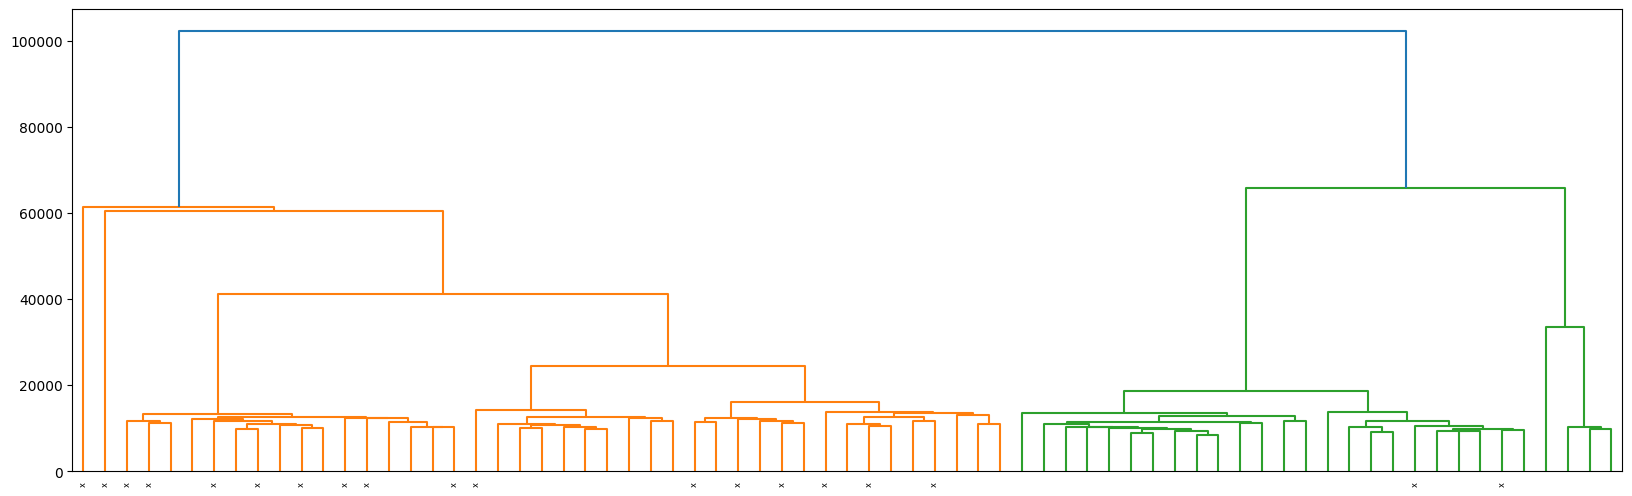

In [2397]:
Z = linkage(all_X, method="ward")
plt.figure(figsize=(20, 6))
dendrogram(Z, labels=labs)
plt.show()

In [2398]:
h = min_height_for_group(Z, np.where(labs == "x")[0])
cl = fcluster(Z, t=h, criterion="distance")
flow_clusters = np.unique(cl[labs == "x"])
dtc = unknown_segments[np.isin(cl, flow_clusters)].reset_index(drop=True)

In [2399]:
year = np.array([int(str(i)[:4]) for i in dtc["start"]])
tr_dtc = dtc[year <= 2020].reset_index(drop=True)
te_dtc = dtc[year > 2020].reset_index(drop=True)

print("Training - DTW - HC", compute_statistics(tr_dtc, tr_high_conf_flows))
print("Training - DTW - ALL", compute_statistics(tr_dtc, tr_station_flows))
print("Testing - DTW - HC", compute_statistics(te_dtc, te_high_conf_flows))
print("Testing - DTW - ALL", compute_statistics(te_dtc, te_station_flows))

Training - DTW - HC {'iou': 54.057175904265996, 'recall': 100.0, 'FN': 0, 'precision': 51.11111111111111, 'FP': 22, 'TP': 23}
Training - DTW - ALL {'iou': 47.26778864679858, 'recall': 100.0, 'FN': 0, 'precision': 72.3404255319149, 'FP': 13, 'TP': 34}
Testing - DTW - HC {'iou': 62.99673978675585, 'recall': 100.0, 'FN': 0, 'precision': 71.42857142857143, 'FP': 6, 'TP': 15}
Testing - DTW - ALL {'iou': 50.417902929767614, 'recall': 90.47619047619048, 'FN': 2, 'precision': 90.47619047619048, 'FP': 2, 'TP': 19}


In [2934]:
if_segments = pd.read_csv(f"../output/XP/if/segments/{station}.csv", index_col=0)
dtc = if_segments
dtc["start"] = [obspy.UTCDateTime(i) for i in dtc["start"]]
dtc["stop"] = [obspy.UTCDateTime(i) for i in dtc["stop"]]
dtc = dtc[dtc["stop"] - dtc["start"] > 300].reset_index(drop=True)

year = np.array([int(str(i)[:4]) for i in dtc["start"]])
tr_dtc = dtc[year <= 2020].reset_index(drop=True)
te_dtc = dtc[year > 2020].reset_index(drop=True)

print("Training - IF - HC", compute_statistics(tr_dtc, tr_high_conf_flows))
print("Training - IF - ALL", compute_statistics(tr_dtc, tr_station_flows))
print("Testing - IF - HC", compute_statistics(te_dtc, te_high_conf_flows))
print("Testing - IF - ALL", compute_statistics(te_dtc, te_station_flows))

Training - IF - HC {'iou': 31.197845712768252, 'recall': 100.0, 'FN': 0, 'precision': 12.244897959183673, 'FP': 172, 'TP': 24}
Training - IF - ALL {'iou': 41.466944254085554, 'recall': 97.43589743589743, 'FN': 1, 'precision': 19.791666666666664, 'FP': 154, 'TP': 38}
Testing - IF - HC {'iou': 33.72620280665626, 'recall': 100.0, 'FN': 0, 'precision': 10.687022900763358, 'FP': 117, 'TP': 14}
Testing - IF - ALL {'iou': 41.680874493745975, 'recall': 80.48780487804878, 'FN': 8, 'precision': 25.581395348837212, 'FP': 96, 'TP': 33}


In [2401]:
import numpy as np
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score


def label_informed_silhouette(X, Z, labeled_indices, k_range):
    """
    Find the number of clusters k that maximizes silhouette score for labeled points.

    Parameters
    ----------
    X : ndarray, shape (n_samples, n_features)
        Full dataset.
    Z : ndarray
        Linkage matrix from scipy.cluster.hierarchy.linkage
    labeled_indices : list or array
        Indices of labeled points in X
    k_range : iterable
        Candidate numbers of clusters

    Returns
    -------
    best_k : int
        Number of clusters maximizing silhouette of labeled points
    best_score : float
        Corresponding silhouette score
    labels_best : ndarray
        Cluster labels for all points at best_k
    """
    best_score = -1
    best_k = None
    labels_best = None

    for k in k_range:
        labels = fcluster(Z, t=k, criterion="maxclust")
        labels_labeled = labels[labeled_indices]

        # Silhouette is undefined if there is only one cluster among labeled points
        if len(np.unique(labels_labeled)) < 2:
            continue

        score = silhouette_score(X[labeled_indices], labels_labeled)

        if score > best_score:
            best_score = score
            best_k = k
            labels_best = labels

    return best_k, best_score, labels_best

In [2466]:
labeled_indices = np.where(labs == "x")[0]
cl = label_informed_silhouette(X, Z, labeled_indices, 1 + np.arange(10))[2]
flow_clusters = np.unique(cl[labs == "x"])

In [2467]:
cl

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 2, 1, 1, 1, 2, 2, 1, 1, 2, 2, 1, 1, 2,
       2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 2, 1, 2, 2, 1, 2,
       2, 2, 1, 2, 2], dtype=int32)

In [2453]:
t = 25000

In [ ]:
# cl = fcluster(Z, t=t, criterion='distance')
flow_clusters = np.unique(cl[labs == "x"])
# t *= 2

In [2468]:
for flc in flow_clusters:
    print(flc, np.sum((cl == flc) * (labs == "x")))

1 17
2 2


In [2469]:
h = min_height_for_group(Z, np.where(cl == 1)[0])
cl = fcluster(Z, t=h, criterion="distance")
flow_clusters = np.unique(cl[labs == "x"])

In [2470]:
flow_clusters

array([1, 2], dtype=int32)

In [2471]:
dtc = unknown_segments[np.isin(cl, flow_clusters)].reset_index(drop=True)

In [2472]:
year = np.array([int(str(i)[:4]) for i in dtc["start"]])
tr_dtc = dtc[year <= 2020].reset_index(drop=True)
te_dtc = dtc[year > 2020].reset_index(drop=True)

print("Training - DTW - HC", compute_statistics(tr_dtc, tr_high_conf_flows))
print("Training - DTW - ALL", compute_statistics(tr_dtc, tr_station_flows))
print("Testing - DTW - HC", compute_statistics(te_dtc, te_high_conf_flows))
print("Testing - DTW - ALL", compute_statistics(te_dtc, te_station_flows))

Training - DTW - HC {'iou': 54.690437073780494, 'recall': 100.0, 'FN': 0, 'precision': 56.09756097560976, 'FP': 18, 'TP': 23}
Training - DTW - ALL {'iou': 47.68365318776311, 'recall': 100.0, 'FN': 0, 'precision': 79.06976744186046, 'FP': 9, 'TP': 34}
Testing - DTW - HC {'iou': 62.99673978675585, 'recall': 100.0, 'FN': 0, 'precision': 71.42857142857143, 'FP': 6, 'TP': 15}
Testing - DTW - ALL {'iou': 50.417902929767614, 'recall': 90.47619047619048, 'FN': 2, 'precision': 90.47619047619048, 'FP': 2, 'TP': 19}


In [2334]:
if_segments = pd.read_csv(f"../output/XP/if/segments/{station}.csv", index_col=0)
dtc = if_segments
dtc["start"] = [obspy.UTCDateTime(i) for i in dtc["start"]]
dtc["stop"] = [obspy.UTCDateTime(i) for i in dtc["stop"]]
dtc = dtc[dtc["stop"] - dtc["start"] > 300].reset_index(drop=True)

year = np.array([int(str(i)[:4]) for i in dtc["start"]])
tr_dtc = dtc[year <= 2020].reset_index(drop=True)
te_dtc = dtc[year > 2020].reset_index(drop=True)

print("Training - IF - HC", compute_statistics(tr_dtc, tr_high_conf_flows))
print("Training - IF - ALL", compute_statistics(tr_dtc, tr_station_flows))
print("Testing - IF - HC", compute_statistics(te_dtc, te_high_conf_flows))
print("Testing - IF - ALL", compute_statistics(te_dtc, te_station_flows))

Training - IF - HC {'iou': 1.1777455057539552, 'recall': 83.33333333333333, 'FN': 2, 'precision': 1.2269938650306749, 'FP': 805, 'TP': 10}
Training - IF - ALL {'iou': 1.4632779964721618, 'recall': 63.63636363636363, 'FN': 8, 'precision': 1.7220172201722017, 'FP': 799, 'TP': 14}
Testing - IF - HC {'iou': 3.200320537667064, 'recall': 91.66666666666667, 'FN': 1, 'precision': 1.5647226173541962, 'FP': 692, 'TP': 11}
Testing - IF - ALL {'iou': 4.668498756213721, 'recall': 49.152542372881356, 'FN': 30, 'precision': 4.131054131054131, 'FP': 673, 'TP': 29}


In [2321]:
h

99720.7572736118

In [2291]:
cl

array([ 1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        8,  8,  1,  1,  1,  1,  1,  1,  2,  3,  1,  2,  1,  1,  3,  1, 18,
       12,  3,  2,  6,  6, 17,  6,  3,  7, 11,  5,  6,  6, 11,  6, 14, 11,
       19,  3,  7, 10,  6, 15, 13, 11,  2, 11, 10, 11,  3, 11, 11, 10, 16,
       16, 10, 13, 15,  3,  4,  3,  9, 13, 10, 15,  3, 14, 13,  2, 15, 14,
       15, 15,  3, 14, 14,  3, 14, 14, 14, 15, 14, 14, 14, 14, 14,  4, 14,
       14, 14, 13, 14, 14, 14, 14, 14, 16, 14,  2, 14, 14,  3, 14, 13, 13,
       13, 14, 13], dtype=int32)

In [2191]:
cl

array([ 3,  1,  1,  3,  3,  1, 11,  1,  1, 19, 20,  1,  6,  3, 21,  2,  3,
        1, 20, 21,  1, 14, 21,  2, 10,  1,  3,  6,  3,  3,  3, 21,  1,  3,
        2, 10,  1, 21,  3,  1, 13,  6, 11, 13,  1,  6,  2,  6,  1,  9,  9,
       14,  1,  1,  1, 11,  5, 13,  9, 10,  1, 17, 14, 11,  3,  9,  9, 10,
        6,  6,  9,  1,  3, 12,  1,  1, 21, 19, 13,  1, 17,  5, 21,  9, 12,
        2,  1,  2,  1,  8,  1, 17,  1,  6,  1, 12,  9,  5, 16,  2,  9, 13,
        6, 14, 13,  9,  3, 19,  1,  1, 19,  1, 17,  1,  1, 18,  1, 13,  6,
        1, 15, 17,  5,  5, 16, 14,  8,  2,  1,  9,  1,  7,  1, 13, 21, 14,
        5, 19,  1, 14, 16,  1, 12,  2, 17,  1, 17,  5, 21,  1, 17,  1, 18,
       21, 15, 15,  2, 19,  8, 15, 15,  4, 14, 19,  5,  4, 19,  2, 16, 15,
       21, 17,  8, 18,  2, 17,  2, 21,  5, 15, 16,  1,  8, 15,  5, 15,  8,
       19, 15,  2,  9, 15,  8, 18,  1, 15, 15, 15,  8, 15,  2, 15, 19,  2,
       21,  4, 15, 19,  2, 15, 15, 18,  9, 15, 21, 15,  2, 21,  5,  9, 18,
       15, 21,  8, 15,  2

In [2174]:
cl.shape

(344,)

In [2175]:
labeled_indices

array([  3,   4,  11,  17,  32,  39,  52,  54,  60,  75,  90,  94, 109,
       114, 138, 142], dtype=int64)

In [606]:
pvals = []

crit_val = np.max(Dw)
nsamples = 1000
nseg = Dw.shape[0]
for j in range(len(seg_info)):
    d = np.array([np.median(seg_info[j][i][0]) for i in range(Dw.shape[0])])
    count = 0
    for i in range(nseg):
        D = Dw.copy()
        idx = np.arange(Dw.shape[0])
        idx = np.delete(idx, i)
        # subsample = np.random.choice(idx, size=len(idx)-1, replace=True)
        # test_stat = max(np.max(Dw[subsample,:][:,subsample]),np.max(d[subsample]))

        D[idx, i] = d[idx]
        D[i, idx] = d[idx]

        test_stat = np.max(max(np.max(Dw[idx, :][:, idx]), np.max(d[idx])))

        if test_stat <= crit_val:
            count += 1
    pval = count / nseg
    pvals.append(pval)

pvals = np.array(pvals)

In [607]:
flows = preproc_flow_annotations(
    pd.read_csv("../catalogs/XP/flow_catalog.csv", index_col=0)
)
tr_lower_conf_flows, tr_high_conf_flows, _ = extract_split_flows(
    flows, station, 2018, 2020
)
tr_station_flows = pd.concat([tr_lower_conf_flows, tr_high_conf_flows]).reset_index(
    drop=True
)

te_lower_conf_flows, te_high_conf_flows, _ = extract_split_flows(
    flows, station, 2021, 2022
)
te_high_conf_flows = te_high_conf_flows.drop(te_high_conf_flows.index[-1])
te_station_flows = pd.concat([te_lower_conf_flows, te_high_conf_flows]).reset_index(
    drop=True
)

In [608]:
dtc = unknown_segments[pvals >= 0.05].reset_index(drop=True)
year = np.array([int(str(i)[:4]) for i in dtc["start"]])
tr_dtc = dtc[year <= 2020].reset_index(drop=True)
te_dtc = dtc[year > 2020].reset_index(drop=True)

print("Training - DTW - HC", compute_statistics(tr_dtc, tr_high_conf_flows))
print("Training - DTW - ALL", compute_statistics(tr_dtc, tr_station_flows))
print("Testing - DTW - HC", compute_statistics(te_dtc, te_high_conf_flows))
print("Testing - DTW - ALL", compute_statistics(te_dtc, te_station_flows))

Training - DTW - HC {'iou': 42.70211427376632, 'recall': 95.83333333333333, 'FN': 1, 'precision': 35.9375, 'FP': 41, 'TP': 23}
Training - DTW - ALL {'iou': 50.7059889680888, 'recall': 84.61538461538461, 'FN': 6, 'precision': 53.2258064516129, 'FP': 29, 'TP': 33}
Testing - DTW - HC {'iou': 42.83813007284392, 'recall': 100.0, 'FN': 0, 'precision': 22.950819672131146, 'FP': 47, 'TP': 14}
Testing - DTW - ALL {'iou': 45.572532595221396, 'recall': 65.85365853658537, 'FN': 14, 'precision': 44.26229508196721, 'FP': 34, 'TP': 27}


In [475]:
dtc = unknown_segments.iloc[dtc == np.min(dtc)].reset_index(drop=True)

In [59]:
flows = preproc_flow_annotations(
    pd.read_csv("../catalogs/XP/flow_catalog.csv", index_col=0)
)
tr_lower_conf_flows, tr_high_conf_flows, _ = extract_split_flows(
    flows, station, 2018, 2020
)
tr_station_flows = pd.concat([tr_lower_conf_flows, tr_high_conf_flows]).reset_index(
    drop=True
)

te_lower_conf_flows, te_high_conf_flows, _ = extract_split_flows(
    flows, station, 2021, 2022
)
te_high_conf_flows = te_high_conf_flows.drop(te_high_conf_flows.index[-1])
te_station_flows = pd.concat([te_lower_conf_flows, te_high_conf_flows]).reset_index(
    drop=True
)

In [17]:
year = np.array([int(str(i)[:4]) for i in dtc["start"]])

tr_dtc = dtc[year <= 2020].reset_index(drop=True)
te_dtc = dtc[year > 2020].reset_index(drop=True)
print("Training - DTW - HC", compute_statistics(tr_dtc, tr_high_conf_flows))
print("Training - DTW - ALL", compute_statistics(tr_dtc, tr_station_flows))
print("Testing - DTW - HC", compute_statistics(te_dtc, te_high_conf_flows))
print("Testing - DTW - ALL", compute_statistics(te_dtc, te_station_flows))

Training - DTW - HC {'iou': 5.630408952295861, 'recall': 100.0, 'FN': 0, 'precision': 2.878787878787879, 'FP': 641, 'TP': 19}
Training - DTW - ALL {'iou': 8.088482956089358, 'recall': 90.9090909090909, 'FN': 3, 'precision': 4.580152671755725, 'FP': 625, 'TP': 30}
Testing - DTW - HC {'iou': 4.917804430145792, 'recall': 100.0, 'FN': 0, 'precision': 1.9639934533551555, 'FP': 599, 'TP': 12}
Testing - DTW - ALL {'iou': 10.953661901783404, 'recall': 100.0, 'FN': 0, 'precision': 6.25, 'FP': 570, 'TP': 38}


Training - IF - HC {'iou': 31.197845712768252, 'recall': 100.0, 'FN': 0, 'precision': 12.244897959183673, 'FP': 172, 'TP': 24}
Training - IF - ALL {'iou': 41.466944254085554, 'recall': 97.43589743589743, 'FN': 1, 'precision': 19.791666666666664, 'FP': 154, 'TP': 38}
Testing - IF - HC {'iou': 33.72620280665626, 'recall': 100.0, 'FN': 0, 'precision': 10.687022900763358, 'FP': 117, 'TP': 14}
Testing - IF - ALL {'iou': 41.680874493745975, 'recall': 80.48780487804878, 'FN': 8, 'precision': 25.581395348837212, 'FP': 96, 'TP': 33}


In [19]:
sta_lta_segments = pd.read_csv(
    f"../output/XP/sta_lta/segments/{station}.csv", index_col=0
)
dtc = sta_lta_segments
dtc["start"] = [obspy.UTCDateTime(i) for i in dtc["start"]]
dtc["stop"] = [obspy.UTCDateTime(i) for i in dtc["stop"]]
dtc = dtc[dtc["stop"] - dtc["start"] > 300].reset_index(drop=True)

year = np.array([int(str(i)[:4]) for i in dtc["start"]])
tr_dtc = dtc[year <= 2020].reset_index(drop=True)
te_dtc = dtc[year > 2020].reset_index(drop=True)

print("Training - IF - HC", compute_statistics(tr_dtc, tr_high_conf_flows))
print("Training - IF - ALL", compute_statistics(tr_dtc, tr_station_flows))
print("Testing - IF - HC", compute_statistics(te_dtc, te_high_conf_flows))
print("Testing - IF - ALL", compute_statistics(te_dtc, te_station_flows))

Training - IF - HC {'iou': 1.002435528772229, 'recall': 89.47368421052632, 'FN': 2, 'precision': 1.6113744075829384, 'FP': 1038, 'TP': 17}
Training - IF - ALL {'iou': 1.3962659118000669, 'recall': 69.6969696969697, 'FN': 10, 'precision': 2.1759697256385997, 'FP': 1034, 'TP': 23}
Testing - IF - HC {'iou': 1.3041863947750452, 'recall': 100.0, 'FN': 0, 'precision': 1.7543859649122806, 'FP': 672, 'TP': 12}
Testing - IF - ALL {'iou': 2.224447087326106, 'recall': 81.57894736842105, 'FN': 7, 'precision': 4.512372634643377, 'FP': 656, 'TP': 31}


In [3]:
station = "ILL12"
if_segments = pd.read_csv(f"../output/XP/if/segments/{station}.csv", index_col=0)
flows = preproc_flow_annotations(
    pd.read_csv("../catalogs/XP/initial_catalog.csv", index_col=0)
)
lower_conf_flows, high_conf_flows, _ = extract_split_flows(flows, station, 2018, 2020)
I, _, _ = iou(if_segments, high_conf_flows)
unknown_segments = if_segments[np.append(I[0], np.diff(I)) == 0].reset_index(drop=True)[
    ["start", "stop"]
]

In [164]:
unknown_segments["start"] = [obspy.UTCDateTime(i) for i in unknown_segments["start"]]
unknown_segments["stop"] = [obspy.UTCDateTime(i) for i in unknown_segments["stop"]]

In [87]:
df_list = []
for station in stations:
    scores_df = pd.read_csv(f"../output/XP/if/scores/{station}.csv", index_col=0)
    scores_df["start"] = [obspy.UTCDateTime(str(i)) for i in scores_df["start"]]
    scores_df["stop"] = [obspy.UTCDateTime(str(i)) for i in scores_df["stop"]]

    station_flows = (
        flows[flows["station"] == station]
        .reset_index(drop=True)
        .drop(["station", "channel", "Notes"], axis=1)
    )
    labels = np.zeros(len(scores_df))

    for i in range(len(station_flows)):
        tstart = station_flows.iloc[i]["start"]
        tstop = station_flows.iloc[i]["stop"]
        confidence = station_flows.iloc[i]["confidence"]

        if confidence == "low":
            confidence = 0.1
        elif confidence == "med":
            confidence = 0.5
        elif confidence == "high":
            confidence = 1.0

        labels[
            np.where((scores_df["start"] >= tstart) & (scores_df["stop"] <= tstop))[0]
        ] = confidence

    scores_df = scores_df.drop("stop", axis=1)
    scores_df = scores_df.rename(columns={"start": "time"})
    scores_df["debris flow"] = labels
    scores_df.insert(0, "station", np.repeat(station, len(scores_df)))
    scores_df["time"] = scores_df["time"].apply(lambda x: pd.Timestamp(x.datetime))
    scores_df = scores_df[
        (scores_df["time"].dt.month <= 9) & (scores_df["time"].dt.month >= 5)
    ].reset_index(drop=True)

    df_list.append(scores_df)

    print(station)

ILL11
ILL12
ILL13
ILL14
ILL15
ILL16
ILL17
ILL18


In [88]:
df_illgraben_anomaly_scores = pd.concat(df_list).reset_index(drop=True)

In [90]:
df_illgraben_anomaly_scores.to_parquet(
    "../data/df_illgraben_anomaly_scores.parquet", engine="pyarrow", index=False
)

In [ ]:
df_illgraben_anomaly_scores = pd.read_parquet(
    "../data/df_illgraben_anomaly_scores.parquet", engine="pyarrow"
)

,station,time,anomaly_score,std,debris flow
0,ILL11,2018-05-14 14:39:49.650,0.326471,0.677716,0.0
1,ILL11,2018-05-14 14:40:39.650,0.326215,0.675536,0.0
2,ILL11,2018-05-14 14:42:55.610,0.371444,7750.164220,0.0
3,ILL11,2018-05-14 14:43:45.610,0.326951,0.683417,0.0
4,ILL11,2018-05-14 14:44:35.610,0.327217,0.674970,0.0
...,...,...,...,...,...
8274477,ILL18,2022-08-28 17:08:12.010,0.401507,6.366621,0.0
8274478,ILL18,2022-08-28 17:09:02.010,0.391121,5.599805,0.0
8274479,ILL18,2022-08-28 17:09:52.010,0.385146,5.659083,0.0
8274480,ILL18,2022-08-28 17:10:42.010,0.378888,4.910445,0.0


In [92]:
df_illgraben_anomaly_scores["time"]

0         2018-05-14 14:39:49.650
1         2018-05-14 14:40:39.650
2         2018-05-14 14:42:55.610
3         2018-05-14 14:43:45.610
4         2018-05-14 14:44:35.610
                    ...          
8274477   2022-08-28 17:08:12.010
8274478   2022-08-28 17:09:02.010
8274479   2022-08-28 17:09:52.010
8274480   2022-08-28 17:10:42.010
8274481   2022-08-28 17:11:32.010
Name: time, Length: 8274482, dtype: datetime64[ns]

In [67]:
scores_df

,start,time,anomaly_score,std,debris flow
0,ILL11,2018-05-14 14:39:49.650,0.326471,0.677716,0.0
1,ILL11,2018-05-14 14:40:39.650,0.326215,0.675536,0.0
2,ILL11,2018-05-14 14:42:55.610,0.371444,7750.164220,0.0
3,ILL11,2018-05-14 14:43:45.610,0.326951,0.683417,0.0
4,ILL11,2018-05-14 14:44:35.610,0.327217,0.674970,0.0
...,...,...,...,...,...
1133192,ILL11,2022-08-26 21:46:42.110,0.352786,74.191155,0.0
1133193,ILL11,2022-08-26 21:47:32.110,0.353378,75.384119,0.0
1133194,ILL11,2022-08-26 21:48:22.110,0.349790,72.768458,0.0
1133195,ILL11,2022-08-26 21:49:12.110,0.351238,70.502204,0.0


In [49]:
scores_df["start"][labels == 0.1]

47638    2018-06-11T04:20:45.690000Z
47639    2018-06-11T04:21:35.690000Z
47640    2018-06-11T04:22:25.690000Z
47641    2018-06-11T04:23:15.690000Z
47642    2018-06-11T04:24:05.690000Z
                    ...             
48431    2018-06-11T15:21:35.690000Z
48432    2018-06-11T15:22:25.690000Z
48433    2018-06-11T15:23:15.690000Z
48434    2018-06-11T15:24:05.690000Z
48435    2018-06-11T15:24:55.690000Z
Name: start, Length: 798, dtype: object

In [44]:
flows

,station,channel,start,stop,confidence,Notes
0,ILL18,EHZ,2018-05-26T15:38:00.000000Z,2018-05-26T16:49:16.000000Z,low,"Perhaps some activity in the upper catchment, ..."
1,ILL13,EHZ,2018-06-11T03:06:00.000000Z,2018-06-11T15:42:00.000000Z,low,NaN
2,ILL11,HHZ,2018-06-11T04:20:00.000000Z,2018-06-11T15:27:00.000000Z,low,NaN
3,ILL17,EHZ,2018-06-11T10:05:00.000000Z,2018-06-11T11:30:00.000000Z,high,NaN
4,ILL18,EHZ,2018-06-11T10:15:00.000000Z,2018-06-11T11:01:30.000000Z,high,NaN
...,...,...,...,...,...,...
455,ILL14,EHZ,2022-09-08T00:37:00.000000Z,2022-09-08T01:25:00.000000Z,high,NaN
456,ILL16,EHZ,2022-09-08T00:37:00.000000Z,2022-09-08T01:27:00.000000Z,high,NaN
457,ILL17,EHZ,2022-09-08T00:38:00.000000Z,2022-09-08T01:31:00.000000Z,high,NaN
458,ILL12,EHZ,2022-09-08T00:45:00.000000Z,2022-09-08T01:33:00.000000Z,high,NaN


In [ ]:
flows["start"]
# np.where()

(array([47638, 47639, 47640, 47641, 47642, 47643, 47644, 47645, 47646,
        47647, 47648, 47649, 47650, 47651, 47652, 47653, 47654, 47655,
        47656, 47657, 47658, 47659, 47660, 47661, 47662, 47663, 47664,
        47665, 47666, 47667, 47668, 47669, 47670, 47671, 47672, 47673,
        47674, 47675, 47676, 47677, 47678, 47679, 47680, 47681, 47682,
        47683, 47684, 47685, 47686, 47687, 47688, 47689, 47690, 47691,
        47692, 47693, 47694, 47695, 47696, 47697, 47698, 47699, 47700,
        47701, 47702, 47703, 47704, 47705, 47706, 47707, 47708, 47709,
        47710, 47711, 47712, 47713, 47714, 47715, 47716, 47717, 47718,
        47719, 47720, 47721, 47722, 47723, 47724, 47725, 47726, 47727,
        47728, 47729, 47730, 47731, 47732, 47733, 47734, 47735, 47736,
        47737, 47738, 47739, 47740, 47741, 47742, 47743, 47744, 47745,
        47746, 47747, 47748, 47749, 47750, 47751, 47752, 47753, 47754,
        47755, 47756, 47757, 47758, 47759, 47760, 47761, 47762, 47763,
      

In [11]:
scores_df

,start,stop,anomaly_score,std
0,2018-05-14T14:39:49.650000Z,2018-05-14T14:41:29.650000Z,0.326471,0.677716
1,2018-05-14T14:40:39.650000Z,2018-05-14T14:42:19.650000Z,0.326215,0.675536
2,2018-05-14T14:42:55.610000Z,2018-05-14T14:44:35.610000Z,0.371444,7750.164220
3,2018-05-14T14:43:45.610000Z,2018-05-14T14:45:25.610000Z,0.326951,0.683417
4,2018-05-14T14:44:35.610000Z,2018-05-14T14:46:15.610000Z,0.327217,0.674970
...,...,...,...,...
1133192,2022-08-26T21:46:42.110000Z,2022-08-26T21:48:22.110000Z,0.352786,74.191155
1133193,2022-08-26T21:47:32.110000Z,2022-08-26T21:49:12.110000Z,0.353378,75.384119
1133194,2022-08-26T21:48:22.110000Z,2022-08-26T21:50:02.110000Z,0.349790,72.768458
1133195,2022-08-26T21:49:12.110000Z,2022-08-26T21:50:52.110000Z,0.351238,70.502204


In [10]:
flows

,station,start,stop,confidence
0,ILL11,2022-06-05T11:22:00.000000Z,2022-06-05T12:29:00.000000Z,high
1,ILL11,2022-07-04T06:59:00.000000Z,2022-07-04T06:59:00.000000Z,earthquake
2,ILL11,2022-07-04T21:48:00.000000Z,2022-07-04T22:39:00.000000Z,high
3,ILL12,2022-06-05T11:20:00.000000Z,2022-06-05T11:57:00.000000Z,high
4,ILL12,2022-06-30T20:33:00.000000Z,2022-06-30T21:08:00.000000Z,high
...,...,...,...,...
322,ILL18,2021-07-06T18:46:00.000000Z,2021-07-06T19:11:00.000000Z,high
323,ILL18,2021-07-13T04:35:00.000000Z,2021-07-13T07:32:00.000000Z,med
324,ILL18,2021-07-13T14:57:00.000000Z,2021-07-13T17:28:00.000000Z,high
325,ILL18,2021-07-16T03:36:00.000000Z,2021-07-16T04:41:00.000000Z,high
